# Compas Analysis - Nicholas Botti - Python Version

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [109]:
#If needed: Install packages
!pip install pandas numpy matplotlib scikit-learn lifelines lime shap dice-ml solas-ai statsmodels scipy

In [2]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

#Load the data
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)

In [4]:
#Look at the first 10 obversations of the data
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [5]:
#The variables involved are selected and categorized
numeric_vars = ["age", "priors_count", "days_b_screening_arrest",
                   "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

selected_data = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text',
                          'sex', 'priors_count', 'days_b_screening_arrest',
                          'decile_score', 'is_recid', 'two_year_recid',
                          'c_jail_in', 'c_jail_out']]
# ── Filtering ────────────────────────────────────────────────────
selected_data = selected_data[(selected_data['days_b_screening_arrest'] >= -30) & (selected_data['days_b_screening_arrest'] <= 30)]
selected_data = selected_data[selected_data['is_recid'] != -1]
selected_data = selected_data[selected_data['c_charge_degree'] != '0']
selected_data = selected_data[selected_data['score_text'] != 'N/A']

# ── Type conversions ─────────────────────────────────────────────
for col in datetime_vars:
    selected_data[col] = pd.to_datetime(selected_data[col], format="%Y-%m-%d %H:%M:%S", utc=True)
#and...
for col in selected_data.columns:
    if col not in numeric_vars and col not in datetime_vars:
        selected_data[col] = selected_data[col].astype('category')
# ── Derived factors with reference levels ─────────────────────────
selected_data["crime_factor"] = selected_data["c_charge_degree"].astype("category")

selected_data["age_factor"] = pd.Categorical(selected_data["age_cat"], categories=["25 - 45", "Less than 25", "Greater than 45"], ordered=False)

selected_data["race_factor"] = pd.Categorical(selected_data["race"], categories=["Caucasian", "African-American", "Other"], ordered=False)

selected_data["gender_factor"] = pd.Categorical(selected_data["sex"], categories=["Male", "Female"])

selected_data["score_factor"] = pd.Categorical(
    selected_data["score_text"] != "Low",
    categories=[False, True]
).rename_categories(["LowScore", "HighScore"])

#Check number of observations after these commands
len(selected_data)


6172

In [6]:
#See the first 10 observations of the selected_data, the dataframe after manipulating a lot of the data.
selected_data.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [7]:
#Look at the type of data each column is, the name of the column, and other conditions acceptable data in each column has
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Below, we calculate and find that higher COMPAS scores are slightly correlated with a longer length of stay. This positive correlation suggests that individuals with higher COMPAS scores tend to have longer stays, though this may reflect judicial decisions or systemic factors rather than a causal relationship.

In [8]:
#Calculating the length of the stay using the jail in time and jail out time, focusing on the days from that data
selected_data["length_of_stay"] = (pd.to_datetime(selected_data["c_jail_out"]) - pd.to_datetime(selected_data["c_jail_in"])).dt.days
#Calculating the correlation
correlation = selected_data['length_of_stay'].corr(selected_data['decile_score'])
print(correlation)

0.20747808478031807


After filtering we have the following demographic breakdown:

The age distribution shows that the majority of observations (3,532) fall between ages 25–45, with fewer individuals under 25 (1,347) and over 45 (1,293). This imbalance means that younger and older individuals outside of the 25-45 age group are underrepresented, limiting the model’s ability to accurately learn patterns for those age groups.

In [9]:
#See how many observations are allocated to different age categories
selected_data["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


Below, we see that 3,175 observations identify as African-American, 2,103 are Caucasian, 509 are Hispanic, 343 are Other, 31 are Asian, and 11 are Native American.

In [10]:
#See how many observations are allocated to different age categories
selected_data["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


We observe that over half of the observations are Black defendants, while 34% are White defendants, suggesting that Black individuals may be overrepresented in the dataset. This imbalance raises concerns about (and could contribute to) potential bias in the COMPAS model, as it may be trained on data that reflect systemic patterns in arrests (like targeted policing in certain neighborhoods) rather than underlying criminal behavior. Additionally, the data may not fully account for socioeconomic factors or historical inequalities, which can further bias risk predictions.

In [11]:
#Using the counts above, figure out the percentage of the observations that are Black defendants, White defendants, Hispanic defendants, Asian defendants, and Native American defendants
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


Below it is seen that 3,421 of the observations have a low COMPAS score, 1,607 have a medium COMPAS score, and 1,144 have a high COMPAS score. We see that the model tends to assign lower COMPAS scores to most defendants, which indicate low-risk. Conversely, only fewer are categoried with a high COMPAS score, indicating high-risk. If the model is trained on this, it makes it so that predictions for high-risk individuals are based on a smaller sample, which could reduce reliability and increase variability in that group.

In [12]:
#See the counts of the observations allocated across risk scores - Low, Medium, and High
selected_data["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


Next, the value counts between race and sex are examined to see the composite of the demographic data that is in this dataset. We see that majority of the dataset is comprised of African-American males. On top of this, there are overwhelmingly more males than female in the data given. This indicates a demographic imbalance. This imbalance can be a factor that brings bias into the model, as it is trained primarily on African-American Males, potentially limiting its ability to generalize accurately to underrepresented groups, particularly females and non–African-American individuals.

In [13]:
#Construct a crosstab that shows the allocation of observations between sex and race
pd.crosstab(selected_data['sex'], selected_data['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


The data also has significantly more males than female in the dataset. As a result, the model may be trained on males, but when needing to generalize to females, could not be as accurate.

In [14]:
#See the distribution of the observations across sex - Male and Female
selected_data["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


Percentage wise, 80.96% of the dataset are males, whereas 19.04% are females, further strengthening the point that males are overrepresented in the data, and could cause biases for the model as it trains.

In [15]:
#Print neatly the percentages of the sex represented in the data
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


Below shows how many people were reoffended within 2 years, which can be used to get the base rate of recidivism (next line of code). This is important when evaluating the model performance and identifying potential imbalances.

In [16]:
#Show how many observations were reoffended within 2 years
len(selected_data[selected_data["two_year_recid"] == 1])

2809

We see that the base rate of recidivism is 45.51%. This is the percentage of people actually reoffended (within 2 years). The nearly half of the sample reoffending is a key baseline for evaluating how useful COMPAS predictions are.

In [17]:
#Divide the number of obersations that were reoffended within 2 years by the total amount of observations to get the rate
len(selected_data[selected_data["two_year_recid"] == 1]) / len(selected_data) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants. Conversely, there is not a clear trend in the decile scores as those scores increase for black defendants. This means that the COMPAS decile scores may be more consistent and predictive of recidivism for White defendants, but not as consistent and predictive for Black defendants (because higher scores don't correspond to higher observed risk). This raises concerns about the fairness of the risk scores.

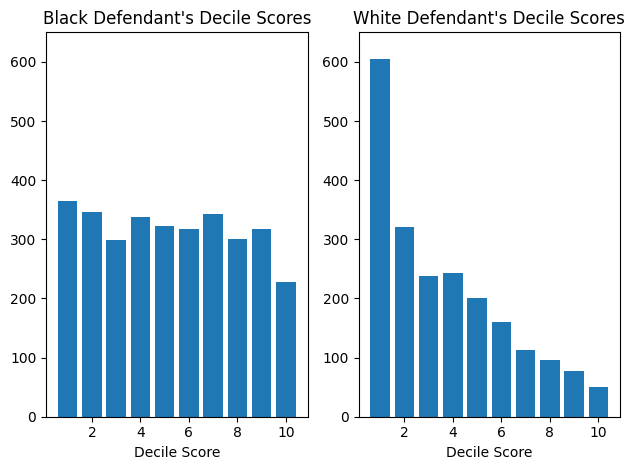

In [18]:
import matplotlib.pyplot as plt

# Filter the data, splitting it into Black and White defendants
black = selected_data[selected_data["race"] == "African-American"]
white = selected_data[selected_data["race"] == "Caucasian"]

# Count how many people fall into each decile score for each group
black_counts = black["decile_score"].value_counts().sort_index()
white_counts = white["decile_score"].value_counts().sort_index()

# Create two charts side by side
fig, axes = plt.subplots(1, 2)

# Left chart: Black defendants
# Shows how COMPAS scores are distributed for this group
axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# Right chart: White defendants
# Shows how COMPAS scores are distributed for this group
axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

To see the distribution of all observations across each race category in the dataset, a crosstab was creating. While it's difficult to interpret the results based on the table, we can see that African Americans face less of a downward trend as decile scores increase, supporting the conclusion above and raising concerns about fairness.

In [19]:
#Create a crosstab table with decile-score (1-10) and race (African-American, Asian, Caucasian, Hispanic, Native American, and Other)
pd.crosstab(selected_data['decile_score'], selected_data['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

The positive and statistically significant coefficient for African-American defendants indicates that, holding other factors constant (such as age, prior offenses, gender, and recidivism), African-American individuals have higher odds of being classified as high risk compared to the reference group (White defendants).

In [20]:
import pandas as pd
import statsmodels.api as sm

df = selected_data.copy()

# Convert to categorical
df['crime_factor'] = df['c_charge_degree'].astype('category')
df['age_factor'] = df['age_cat'].astype('category')
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)
df['gender_factor'] = pd.Categorical(
    df['sex'],
    categories=['Male', 'Female'],
    ordered=False
)

# Create target variable
df['score_factor'] = (df['score_text'] != "Low").astype(int)   # 1 = HighScore, 0 = LowScore

# Create design matrix
X = pd.get_dummies(
    df[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']],
    drop_first=True
)

# Convert booleans to ints if needed
X = X.astype(int)

y = df['score_factor']

# Add intercept
X_sm = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X_sm)
result = model.fit()

# Full summary
print(result.summary())

# Coefficients + p-values table
summary_df = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues
})

print(summary_df)

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        03:57:10   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.5255      0.079    -19.430      0.000

After calculating the probability from the coefficients of the logistic regresison, we see that Black defendants are 45% more likely than White defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
import numpy as np

# Calculate the baseline probability (control)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# Calculate probability using the African-American coefficient
answer = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

print(answer)

1.4528408658138932


Additionally, we see that Women are 19.4% more likely than men to get a higher score. This suggests that gender could play a role in the model's risk classification, but not as significant as the other disparities that have been pointing out so far.

In [22]:
#Calculate the probability using the Women coefficient
answer = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))
print(answer)

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants. This suggests that younger individual are perceived as higher risk, which could be due higher recidivism among younger populations.

In [23]:
#Calculate the probaility using the Less than 25 coefficient
answer = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))
print(answer)

2.4961202077189455


### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [24]:
import pandas as pd

#Read in the new data file and see how many observations the data has
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv'
violent_df = pd.read_csv(url)
len(violent_df)

4743

In [25]:
#Select the columns necessary for the logistic regression that will test for racial bias
selected_data_violent = violent_df[['age', 'c_charge_degree', 'race', 'age_cat', 'v_score_text',
                          'sex', 'priors_count', 'days_b_screening_arrest',
                          'v_decile_score', 'is_recid', 'two_year_recid']]
# ── Filtering ────────────────────────────────────────────────────
selected_data_violent = selected_data_violent[(selected_data_violent['days_b_screening_arrest'] >= -30) & (selected_data_violent['days_b_screening_arrest'] <= 30)]
selected_data_violent = selected_data_violent[selected_data_violent['is_recid'] != -1]
selected_data_violent = selected_data_violent[selected_data_violent['c_charge_degree'] != '0']
selected_data_violent = selected_data_violent[selected_data_violent['v_score_text'] != 'N/A']
len(selected_data_violent)

4020

When looking at the composition of age below in this dataset, it is evident that 25-45 are majority of the data, indicating overrepresentation and bias.

In [26]:
#Show the distribution of observations in age among three categories: 25-45, Greater than 45, and Less than 25
selected_data_violent["age_cat"].value_counts()

,count
age_cat,
25 - 45,2300
Greater than 45,954
Less than 25,766


Next, we see that majority of the observations are African-American in this dataset.

In [27]:
#Show the distribution of observations in race
selected_data_violent["race"].value_counts()

,count
race,
African-American,1918
Caucasian,1459
Hispanic,355
Other,255
Asian,26
Native American,7


The scores that aim to measure a persons risk of violent recidivism is Low for majority of the observations in this dataset. While individuals are posing a relatively low risk of committing a violent offense in the future in this dataset, the imbalance can mean that there are less medium and high-risk cases to train on, which makes it more difficult for the model to accurately distinguish truly high-risk individuals.

In [28]:
#Show the distribution of observations based on the v-score text
selected_data_violent["v_score_text"].value_counts()

,count
v_score_text,
Low,2913
Medium,828
High,279


We see that the base rate of recidivism has been reduced to 16.22% in the case of the violent scores data. This is the percentage of people actually reoffended (within 2 years), and indicates that violent recidivism is much less common than general recidivism. This can make the model preiction more difficult, as the model is identifying a small group of true reoffenders, reducing accuracy.

In [29]:
#Divide the number of observations of true offenders by the total amount of observations in the data
len(selected_data_violent[selected_data_violent["two_year_recid"] == 1]) / len(selected_data_violent) * 100

16.218905472636816

In total, 652 observations were reoffended within 2 years, quantifying the small sample of true reoffenders.

In [30]:
#Show the number of observations of true offenders
len(selected_data_violent[selected_data_violent['two_year_recid'] == 1])

652

To get a solid understanding of the relationship (and assignment) of violent decile scores between Black and White defendants, a bar chart was created, with the x-axis being the increasing violent decile score, and the y-axis being the counts of each score in the data. In comparison to the general decile scores analyzed earlier in the notebook, Black defendants see a steeper downward trend in count as violent decile scores increase, matching more of what the White defendants distribution looks like. However, it is still clear that White defendants receive lower deciles scores than Black defendants. There is a steep drop off of violent decile scores in the White defendant chart, going from score 1 to 2. This suggests that, even in the context of violent recidivism where overall risk is lower, Black defendants may still be disproportionately assigned higher risk scores, raising concerns about potential bias in how the model evaluates risk across racial groups.

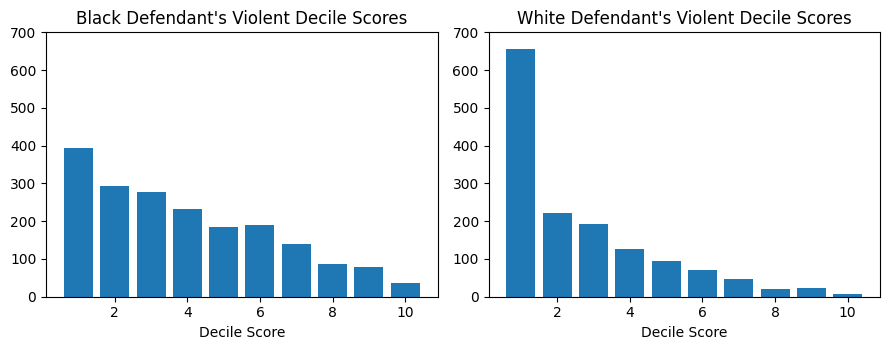

In [31]:
import matplotlib.pyplot as plt

#Filter the data, splitting it into Black and White defendants
black = selected_data_violent[selected_data_violent["race"] == "African-American"]
white = selected_data_violent[selected_data_violent["race"] == "Caucasian"]

#Count how many people fall into each decile score for each group
black_counts = black["v_decile_score"].value_counts().sort_index()
white_counts = white["v_decile_score"].value_counts().sort_index()

#Create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

#Left Chart: Black defendants
#Shows how COMPAS scores are distributed for this group
axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 700)

#Right Chart: White defendants
#Shows how COMPAS scores are distributed for this group
axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

By building a logistic regression, we can gather statistical findings that signify the significance of the biases that the model may show after being trained on this particular data.

The coefficient for African-American defendants is positive (0.659) and statistically significant (p < 0.001), meaning they have about 93% higher odds of receiving a high violent risk score compared to White defendants, holding other factors constant. Compared to the general logistic regression earlier, the affect of race is stronger, suggesting that it plays an bigger role in how violent risk scores are assigned.

In [32]:
import pandas as pd
import statsmodels.api as sm

dfv = selected_data_violent.copy()

# Convert to categorical
dfv['crime_factor'] = dfv['c_charge_degree'].astype('category')
dfv['age_factor'] = dfv['age_cat'].astype('category')
dfv['race_factor'] = pd.Categorical(
    dfv['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)
dfv['gender_factor'] = pd.Categorical(
    dfv['sex'],
    categories=['Male', 'Female'],
    ordered=False
)

# Create target variable
dfv['v_score_factor'] = (dfv['v_score_text'] != "Low").astype(int)   # 1 = HighScore, 0 = LowScore

# Create design matrix
X = pd.get_dummies(
    dfv[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']],
    drop_first=True
)

# Convert booleans to ints if needed
X = X.astype(int)

y = dfv['v_score_factor']

# Add intercept
X_sm = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X_sm)
result = model.fit()

# Full summary
print(result.summary())

# Coefficients + p-values table
summary_dfv = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues
})

print(summary_dfv)

Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         v_score_factor   No. Observations:                 4020
Model:                          Logit   Df Residuals:                     4008
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.3662
Time:                        03:57:12   Log-Likelihood:                -1499.4
converged:                       True   LL-Null:                       -2365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.2427      0.113    -19.802      0.000

To put it simply, probabilities were calculated to show that Black defendants have significantly higher likelihood of being assigned a high violent risk score compared to White defendants. This suggests that, even when controlling for other factors, race is associated with higher predicted risk, raising concerns about potential bias in how the scores are assigned.

In [33]:
import numpy as np
# Calculate the baseline probability (control)
control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
# Calculate probability using the African-American coefficient
answer = np.exp(0.65893) / (1 - control + (control * np.exp(0.65893)))
print(answer)

1.7739209589164604


Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants. This shows that age plays a very strong role in the model, with younger individuals being viewed as significantly higher risk, even more so than in the general COMPAS model.

In [34]:
# Calculate probability using the Less than 25 coefficient
answer = np.exp(3.14591) / (1 - control + (control * np.exp(3.14591)))
print(answer)

7.414239863565466


## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [35]:
import pandas as pd

# Load the cox-parsed COMPAS dataset from the link
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv'
data = pd.read_csv(url)

# Remove rows where score is missing, and keep rows where end > start
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

# Turn race into a categorical variable, which Caucasian as the reference group
data["race_factor"] = pd.Categorical(
    data["race"],
    categories=["Caucasian","African-American", "Asian", "Hispanic", "Native American", "Other"])

# Turn score text into a categorical variable
data["score_factor"] = pd.Categorical(data["score_text"])

# Drop any duplicates in the data
grp = data.drop_duplicates(subset="id")

# Print how many unique people are in the dataset
print(len(grp))

10325


Now that the data has been loaded, looking at the distribution of observations between different categories will give us descriptive results to identify what proportions of the observations identify with different scores and races.

First, we see that in this particular data, more Low scores are assigned to different observations than the Medium or High, suggesting that the COMPAS model tends to classify most individuals as lower risk overall.

Secondly, in this dataset, we see that the majority of the observations are African-American (5,150), followed by Caucasian (3,576). This shows a noticeable imbalance in the data, where African-American defendants are more represented than other groups.

In [36]:
#Show the distribution of observations by score
grp["score_factor"].value_counts()

,count
score_factor,
Low,5751
Medium,2611
High,1952


In [37]:
#Show the distribution of observations by race
grp["race_factor"].value_counts()

,count
race_factor,
African-American,5150
Caucasian,3576
Hispanic,944
Other,572
Asian,51
Native American,32


Next, a Cox Proportional Hazards Model must be built to test whether COMPAS scores do a good job of assigning risk to an offender.

In [38]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
dfcph = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
dfcph = dfcph[['start', 'end', 'event', 'score_factor']]

# Turn score into a categorical variable
dfcph['score_factor'] = pd.Categorical(
    dfcph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert score categories into dummy variables for the model
dfcph = pd.get_dummies(dfcph, columns=['score_factor'], drop_first=True)

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
cph.fit(dfcph, duration_col='end', event_col='event', entry_col='start')

# Print the results
cph.print_summary()

# Print concordance
print("Concordance:", cph.concordance_index_)

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30305.85
         time fit was run = 2026-04-06 03:57:13 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.78

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 19.53 <0.005    279.75
score_factor_High      0.00 30.14 <0.005    660.70
---
Concordance = 0.60
Partial AIC = 60615.71
log-likelihood ratio test = 942.82 on 2 df
-log2(p) of ll-ratio test = 680.10

Concordance: 0.5999645747142149


As shown in the outputs above, people placed in the High category are 3.5 times as likely to recidivate (showing that COMPAS score is capturing some level of risk), and the COMPAS system's concordance 60%. This is lower than the accuracy quoted in the Northpoint study of 68%. This suggests that the model may not perform as well on this dataset and that the predictive ability is limited than what was originally claimed.

In [39]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
dfcph = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
dfcph = dfcph[['start', 'end', 'event', 'decile_score']]

# Make sure decile_score is numeric
dfcph['decile_score'] = pd.to_numeric(dfcph['decile_score'], errors='coerce')

# Drop any rows with missing values in key columns
dfcph = dfcph.dropna(subset=['start', 'end', 'event', 'decile_score'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
cph.fit(dfcph, duration_col='end', event_col='event', entry_col='start')

# Print the results
cph.print_summary()

# Print concordance
print("Concordance:", cph.concordance_index_)

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30221.49
         time fit was run = 2026-04-06 03:57:25 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.61 <0.005    820.06
---
Concordance = 0.62
Partial AIC = 60444.98
log-likelihood ratio test = 1111.55 on 1 df
-log2(p) of ll-ratio test = 807.20

Concordance: 0.6209369245927892


COMPAS's decile scores are a bit more accurate at 62%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [40]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
dfcph = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
dfcph = dfcph[['start', 'end', 'event', 'race_factor', 'score_factor']]

# Set reference group for race_factor
dfcph['race_factor'] = pd.Categorical(
    dfcph['race_factor'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

# Set reference group for score_factor
dfcph['score_factor'] = pd.Categorical(
    dfcph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop rows with missing values in key columns
dfcph = dfcph.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model with interaction between race and score
cph.fit(
    dfcph,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30280.41
         time fit was run = 2026-04-06 03:57:29 UTC

---
                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                               
race_factor[T.African-American]                         0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor[T.Asian]                                   -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor[T.Hispanic]                                -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor[T.Native American]                         -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor[T.Other]                                    0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor[T.Medium]                                  0.84      2.32      0.07            0.70            0.98                2.02                2.67
score_factor[T.High]                                    1.28      3.61      0.08            1.12            1.45                3.06                4.25
race_factor[T.African-American]:score_factor[T.Medium] -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
race_factor[T.Asian]:score_factor[T.Medium]             0.99      2.68      0.71           -0.41            2.38                0.67               10.80
race_factor[T.Hispanic]:score_factor[T.Medium]          0.07      1.07      0.16           -0.26            0.39                0.77                1.47
race_factor[T.Native American]:score_factor[T.Medium]   1.39      4.01      1.12           -0.81            3.59                0.45               36.07
race_factor[T.Other]:score_factor[T.Medium]            -0.33      0.72      0.23           -0.79            0.12                0.45                1.13
race_factor[T.African-American]:score_factor[T.High]   -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
race_factor[T.Asian]:score_factor[T.High]               1.32      3.73      0.77           -0.19            2.82                0.83               16.80
race_factor[T.Hispanic]:score_factor[T.High]           -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
race_factor[T.Native American]:score_factor[T.High]     1.96      7.07      1.08           -0.17            4.08                0.85               59.09
race_factor[T.Other]:score_factor[T.High]               0.41      1.51      0.26           -0.09            0.92                0.91                2.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  4.59 <0.005     17.75
race_factor[T.Asian]                                      0.00 -1.55   0.12      3.04
race_factor[T.Hispanic]                                   0.00 -0.66   0.51      0.97
race_factor[T.Native American]                            0.00 -1.25   0.21      2.25
race_factor[T.Other]                                      0.00  0.13   0.90      0.16
score_factor[T.Medium]                                    0.00 11.80 <0.005    104.36
scor

The interaction term shows a similar disparity as the logistic regression above.

High-risk white defendants are 3.61× more likely than low-risk white defendants, while high-risk Black defendants are about 2.99× more likely than low. This shows that higher COMPAS scores are linked to higher recidivism risk for both groups, but the jump from low to high is smaller for Black defendants. In other words, the increase in risk is more pronounced for white defendants, which could mean the score does a better job separating low vs. high risk for whites than it does for Blacks.

In [41]:
#We can see the Hazard scores for each combination of risk and race, relative to the Caucasian, Low Risk reference group.
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


Below is a Kaplan Meiser plot, with time on the x-axis (how long individuals are followed) and survival probability (the probability of not recidivating) on the y-axis. Three lines: low risk, medium risk, and high risk are shown, with low risk having the highest survival curve, and high risk having the lowest survival curve. To interpret the performance of the score, the curve should be well separated. High risk should be recidivating sooners and more often than low risk individuals.

Based on the output, the scores seems to be distinguishing between the risk levels well overall.

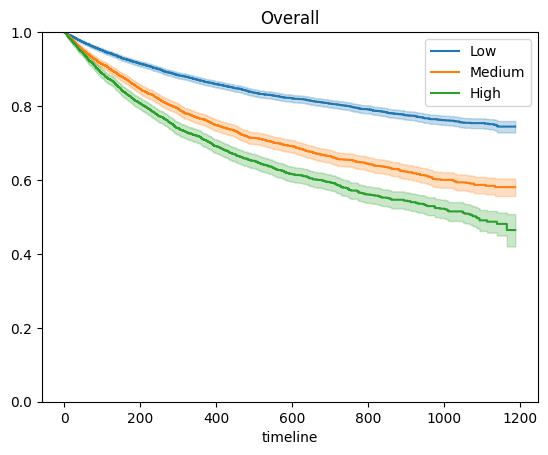

In [42]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

#Fit model
kmf = KaplanMeierFitter()

# Loop through each score group
for score in ["Low", "Medium", "High"]:
    subset = data[data["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ci_show=True)

# Add title and limits
plt.title("Overall")
plt.ylim(0, 1)

# Show plot
plt.show()

Black defendants do recidivate at higher rates according to race specific Kaplan Meier plots. This shows that while overall recidivism levels are higher for Black defendants, the increase in risk across COMPAS score is not as steep as it is for white defendants. This means that even though baseline risk seems to be higher, the score's ability to distinguish between low- and high-risk individuals may be weaker for Black defendants.

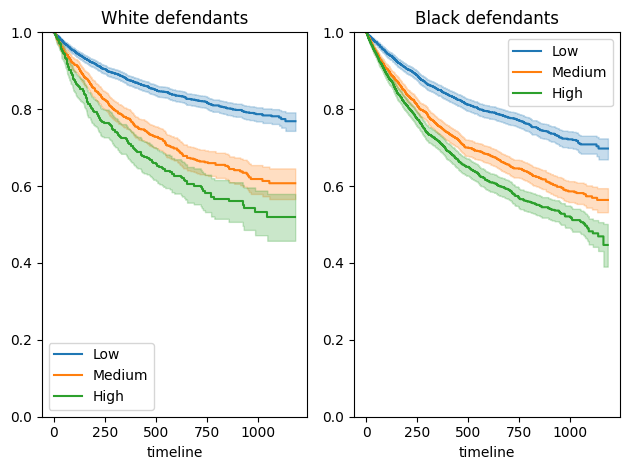

In [43]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = data[data["race"] == "Caucasian"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("White defendants")
axes[0].set_ylim(0, 1)

# Black chart
black = data[data["race"] == "African-American"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Black defendants")
axes[1].set_ylim(0, 1)

# Show plots
plt.tight_layout()
plt.show()

Below, the Kaplan Meiser survival curves are being fitted, and then, the estimated probability of not recidivating at time 730 are shown for each COMPAS risk group. The first code does this for the full sample, and then it is separately examined for the White defendants and Black defendants for comparison. The survival estimate, along with a 95% confidence level, are reported for this comparison.

The results show that survival decreases as risk level increases, with low-risk individuals having the highest survival and high-risk having the least, confirming the score is predictive. However, when you break it down by race, Black defendants have lower survival at every risk level, meaning that they are more likely to be reoffended across the board.

Additionally, the gap between low and high risk is larger for white defendants than for black defendants. This indicates that the score increases risk for both groups, but it differentiates more strongly for White defendants than for Black defendants.

In [44]:
# Create model
kmf = KaplanMeierFitter()

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = data[data["score_factor"] == score]

    # Fit survival curve
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = ci_730.iloc[0, 0]
    upper_730 = ci_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.8021577613594814
Lower 95% CI: 0.791747744020425
Upper 95% CI: 0.8121110234499288

Medium
Survival at 730: 0.6556909315249098
Lower 95% CI: 0.6376255074274386
Upper 95% CI: 0.6730996535819999

High
Survival at 730: 0.580821302329446
Lower 95% CI: 0.559145120078682
Upper 95% CI: 0.6018383488427669



In [45]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["race"] == "African-American"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7430101314698092
Lower 95% CI: 0.7234105111294775
Upper 95% CI: 0.7614582234057639

Medium
Survival at 730: 0.5484618451535137
Lower 95% CI: 0.5217058389977448
Upper 95% CI: 0.5743776469005313

High
Survival at 730: 0.3976132414748815
Lower 95% CI: 0.36969407026993195
Upper 95% CI: 0.4253690324189963



In [46]:
# Create model
kmf = KaplanMeierFitter()

# Filter to White defendants
white = data[data["race"] == "Caucasian"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = white[white["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7946073341971056
Lower 95% CI: 0.7770771557605307
Upper 95% CI: 0.8109312877713442

Medium
Survival at 730: 0.575683295727647
Lower 95% CI: 0.5384816958312129
Upper 95% CI: 0.611033739916427

High
Survival at 730: 0.43472948863102423
Lower 95% CI: 0.3810011895777014
Upper 95% CI: 0.4871685114025509



Race specific models have similar concordance values, with the white model at 60% and the Black model at 58%. The overall predictive performance of the Cox models is therefore nearly the same across both groups, and thus, the model can correctly rank individuals by risk across both groups.

In [47]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
dfcph = white.copy()

# Select columns we need for the model
dfcph = dfcph[['start', 'end', 'event', 'score_factor']]

# Set score_factor as categorical with Low as reference group
dfcph['score_factor'] = pd.Categorical(
    dfcph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop any rows with missing values in key columns
dfcph = dfcph.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
# formula uses Low as the reference group
cph.fit(
    dfcph,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4564 total observations, 3541 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 4564
number of events observed = 1023
   partial log-likelihood = -7919.63
         time fit was run = 2026-04-06 03:58:05 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  0.84      2.32      0.07            0.70            0.98                2.01                2.66
score_factor[T.High]    1.28      3.58      0.08            1.11            1.44                3.04                4.22

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.75 <0.005    103.54
score_factor[T.High]      0.00 15.26 <0.005    172.18
---
Concordance = 0.60
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56

In [48]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
dfcph = black.copy()

# Select columns we need for the model
dfcph = dfcph[['start', 'end', 'event', 'score_factor']]

# Set score_factor as categorical with Low as reference group
dfcph['score_factor'] = pd.Categorical(
    dfcph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop any rows with missing values in key columns
dfcph = dfcph.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
# formula uses Low as the reference group
cph.fit(
    dfcph,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6862 total observations, 4827 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 6862
number of events observed = 2035
   partial log-likelihood = -16302.68
         time fit was run = 2026-04-06 03:58:06 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  0.67      1.95      0.06            0.56            0.78                1.75                2.18
score_factor[T.High]    1.10      2.99      0.05            0.99            1.20                2.69                3.33

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.89 <0.005    105.92
score_factor[T.High]      0.00 20.00 <0.005    293.26
---
Concordance = 0.58
Partial AIC = 32609.37
log-likelihood ratio test = 416.91 on 2 df
-log2(p) of ll-ratio test = 300.74

COMPAS’s violent recidivism score has a slightly higher overall concordance of 63%, indicating modest predictive accuracy. This is somewhat higher than the concordance observed in the separate models for Black and White defendants, suggesting the combined model performs slightly better overall, though accuracy remains limited.

In [49]:
from lifelines import CoxPHFitter
import pandas as pd

# Read the violent dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
violent_data = pd.read_csv(url)

# Keep rows with valid score_text
violent_data = violent_data[violent_data["score_text"] != "N/A"]

# Keep rows where end is greater than start
violent_data = violent_data[violent_data["end"] > violent_data["start"]]

# Create race_factor
violent_data["race_factor"] = pd.Categorical(
    violent_data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

# Create score_factor
violent_data["score_factor"] = pd.Categorical(
    violent_data["score_text"],
    categories=["Low", "Medium", "High"]
)

# Building the model
# Filter data
dfvd = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person for CoxPHFitter
dfvd = dfvd.sort_values("end").drop_duplicates(subset="id", keep="last")

# Keep needed columns
dfvd = dfvd[['start', 'end', 'event', 'score_factor']]

# Set score categories
dfvd['score_factor'] = pd.Categorical(
    dfvd['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop missing values
dfvd = dfvd.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(
    dfvd,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Keep one row per person
vgrp = violent_data.drop_duplicates(subset='id')

# Print number of people
print(len(vgrp))

# Show results
cph.print_summary()

10999


<lifelines.CoxPHFitter: fitted with 10985 total observations, 10167 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 10985
number of events observed = 818
   partial log-likelihood = -6968.34
         time fit was run = 2026-04-06 03:58:09 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  1.00      2.73      0.09            0.83            1.17                2.30                3.23
score_factor[T.High]    1.77      5.90      0.08            1.61            1.94                5.00                6.96

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.51 <0.005     99.46
score_factor[T.High]      0.00 21.04 <0.005    324.13
---
Concordance = 0.63
Partial AIC = 13940.67
log-likelihood ratio test = 431.64 on 2 df
-log2(p) of ll-ratio test = 311.36

In this case, there isn’t a significant coefficient on African Americans with High Scores, meaning their risk of violent recidivism is not statistically different from Caucasians with High Scores. The interaction term is essentially zero and insignificant, so a high COMPAS violent score increases risk similarly across both groups rather than disproportionately for African Americans.

In [50]:
from lifelines import CoxPHFitter
import pandas as pd

# Filter out invalid scores
dfvd = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

dfvd = dfvd.sort_values("end").drop_duplicates(subset="id", keep="last")

# Keep only relevant columns for model
dfvd = dfvd[['start', 'end', 'event', 'race_factor', 'score_factor']]

# Set race_factor as categorical
dfvd['race_factor'] = pd.Categorical(
    dfvd['race_factor'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

# Set score_factor as categorical
dfvd['score_factor'] = pd.Categorical(
    dfvd['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop missing values
dfvd = dfvd.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

# Initialize model
cph = CoxPHFitter()

# Fit model with race, score, and interaction
cph.fit(
    dfvd,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Display model results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10985 total observations, 10167 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 10985
number of events observed = 818
   partial log-likelihood = -6951.94
         time fit was run = 2026-04-06 03:58:11 UTC

---
                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                
race_factor[T.African-American]                          0.23      1.26      0.13           -0.03            0.49                0.97                1.63
race_factor[T.Asian]                                    -0.66      0.52      1.00           -2.62            1.31                0.07                3.72
race_factor[T.Hispanic]                                 -0.22      0.80      0.21           -0.64            0.20                0.52                1.22
race_factor[T.Native American]                         -16.15      0.00   3452.56        -6783.05         6750.75                0.00                 inf
race_factor[T.Other]                                    -0.06      0.94      0.24           -0.54            0.42                0.58                1.51
score_factor[T.Medium]                                   0.81      2.25      0.16            0.50            1.12                1.65                3.07
score_factor[T.High]                                     1.62      5.08      0.17            1.29            1.96                3.62                7.11
race_factor[T.African-American]:score_factor[T.Medium]   0.14      1.15      0.20           -0.25            0.52                0.78                1.69
race_factor[T.Asian]:score_factor[T.Medium]              1.48      4.39      1.23           -0.94            3.90                0.39               49.34
race_factor[T.Hispanic]:score_factor[T.Medium]           0.51      1.66      0.34           -0.16            1.18                0.85                3.26
race_factor[T.Native American]:score_factor[T.Medium]   16.48  1.43e+07   3452.56        -6750.42         6783.38                0.00                 inf
race_factor[T.Other]:score_factor[T.Medium]              0.00      1.00      0.49           -0.96            0.97                0.38                2.63
race_factor[T.African-American]:score_factor[T.High]    -0.00      1.00      0.21           -0.41            0.40                0.67                1.49
race_factor[T.Asian]:score_factor[T.High]                1.31      3.72      1.42           -1.48            4.11                0.23               60.77
race_factor[T.Hispanic]:score_factor[T.High]             0.14      1.15      0.40           -0.64            0.92                0.53                2.51
race_factor[T.Native American]:score_factor[T.High]     17.92  6.04e+07   3452.56        -6748.98         6784.82                0.00                 inf
race_factor[T.Other]:score_factor[T.High]                1.23      3.41      0.40            0.43            2.02                1.54                7.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  1.74   0.08      3.61
race_factor[T.Asian]                                      0.00 -0.65   0.51      0.96
race_factor[T.Hispanic]                                   0.00 -1.04   0.30      1.74
race_factor[T.Native American]                            0.00 -0.00   1.00      0.01
race_factor[T.Other]                                      0.00 -0.25   0.80      0.32
score_factor[T.Medium]                                    0.00  5.12 <0.

In the next three cells, two separate Cox models are build, one for African-American defendants and one for Caucasian defendants. It first filters the data, keeping one row per person, and creates a duration using the start and end time in the violent data. Lastly, the COMPAS score levels are converted into dummy variables so Medium and High levels can be compared to Low in the model.

After this, each model is fit to estimate how Medium and High scores affect the risk of violen recidivism within each group. The output will show the coefficients (as we have seen previous), and the concordans to evaluate predictive accuracy. In the African-American model, the condorance was 63%. Conversely, the Caucasian model has a condorance of 61%.

Lastly, Kaplan Meier curves were plotted for each race and score group, showing the comparison and whether COMPAS scores separate risk levels similarly across Black and White defendants.

In [51]:
from lifelines import CoxPHFitter
import pandas as pd

# Building the model
# Filter data
dfph = violent_data[
    (violent_data["race_factor"] == "African-American") &
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person
dfph = dfph.drop_duplicates(subset='id')

# Create duration variable
dfph["duration"] = dfph["end"] - dfph["start"]

# Keep needed columns
dfph = dfph[['duration', 'event', 'score_factor']]

# Set score categories
dfph['score_factor'] = pd.Categorical(
    dfph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert categories to dummy variables
dfph = pd.get_dummies(dfph, columns=['score_factor'], drop_first=True)

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(dfph, duration_col='duration', event_col='event')

# Print number of people
print(len(dfph))

# Show results
cph.print_summary()

5440


<lifelines.CoxPHFitter: fitted with 5440 total observations, 5141 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5440
number of events observed = 299
   partial log-likelihood = -2418.88
         time fit was run = 2026-04-06 03:58:38 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.65      1.91      0.15            0.36            0.93                1.43                2.55
score_factor_High    1.13      3.11      0.14            0.85            1.41                2.35                4.10

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 4.37 <0.005     16.31
score_factor_High      0.00 7.98 <0.005     49.24
---
Concordance = 0.63
Partial AIC = 4841.75
log-likelihood ratio test = 65.06 on 2 df
-log2(p) of ll-ratio test = 46.93

In [52]:
from lifelines import CoxPHFitter
import pandas as pd

# Building the model
# Filter data
dfph = violent_data[
    (violent_data["race_factor"] == "Caucasian") &
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person
dfph = dfph.drop_duplicates(subset='id')

# Create duration variable
dfph["duration"] = dfph["end"] - dfph["start"]

# Keep needed columns
dfph = dfph[['duration', 'event', 'score_factor']]

# Set score categories
dfph['score_factor'] = pd.Categorical(
    dfph['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert categories to dummy variables
dfph = pd.get_dummies(dfph, columns=['score_factor'], drop_first=True)

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(dfph, duration_col='duration', event_col='event')

# Print number of people
print(len(dfph))

# Print concordance
print("Concordance:", cph.concordance_index_)

# Show results
cph.print_summary()

3821
Concordance: 0.6120039889333156


<lifelines.CoxPHFitter: fitted with 3821 total observations, 3671 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3821
number of events observed = 150
   partial log-likelihood = -1165.78
         time fit was run = 2026-04-06 03:58:38 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.63      1.88      0.19            0.25            1.01                1.29                2.75
score_factor_High    1.37      3.94      0.22            0.95            1.79                2.59                6.02

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 3.26 <0.005      9.80
score_factor_High      0.00 6.37 <0.005     32.31
---
Concordance = 0.61
Partial AIC = 2335.57
log-likelihood ratio test = 36.41 on 2 df
-log2(p) of ll-ratio test = 26.26

The plots below for that for both White and Black defendants, the ordering is very consistent. As we should see (and can expect), low risk has the highest survival, whereas high risk has to lowest survival (survival being the measured by time and the probability of being reoffended). This indicates that the COMPAS score is doing what it's supposed to. Furthermore, the spacing between the levels of risk are similar across both groups. This is good, as this is an indication that the score performs similar across White and Black defendants.

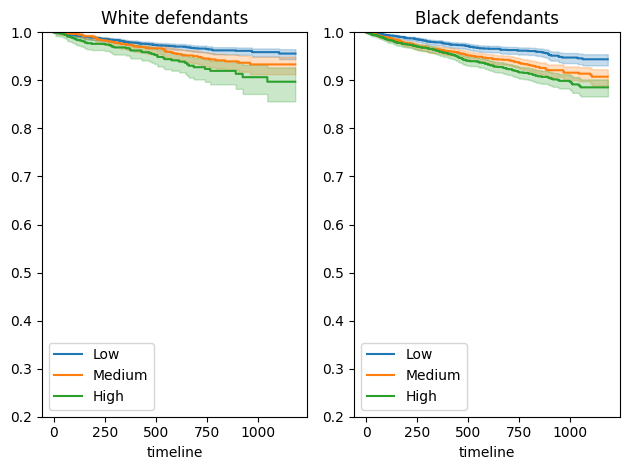

In [53]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = violent_data[violent_data["race"] == "Caucasian"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("White defendants")
axes[0].set_ylim(0.2, 1)

# Black chart
black = violent_data[violent_data["race"] == "African-American"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Black defendants")
axes[1].set_ylim(0.2, 1)

# Show plots
plt.tight_layout()
plt.show()

## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [54]:
import urllib.request

# Download truth_tables.py file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/truth_tables.py",
    "truth_tables.py")

# Download cox-parsed.csv file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv",
    "cox-parsed.csv")

# Import needed classes and functions
from truth_tables import PeekyReader, Person, table, is_race, count, vtable, hightable, vhightable
from csv import DictReader

# Create empty list to store people
people = []

# Read CSV and build Person objects
with open("cox-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

# Keep valid scores and relevant time window
pop = list(filter(
    lambda i: ((i.recidivist == True and i.lifetime <= 730) or i.lifetime > 730),
    list(filter(lambda x: x.score_valid, people))
))

# People who recidivated within 730 days
recid = list(filter(
    lambda i: i.recidivist == True and i.lifetime <= 730,
    pop
))

# Convert recid list to set
rset = set(recid)

# People who did not recidivate within 730 days
surv = [i for i in pop if i not in rset]

We see below that after analysis, 2681 people were correctly labeled Low risk, but 1282 were labeled High risk even though they didn't recidivate (showing overprediction). On the other hand, we see that 2035 were correctly labeled High risk, but 1216 were labeled Low risk even though they did recidivate (underprediction).

The false positive rate shows that about a third of those who did not recidivator were incorrectly labeled high risk, which is indicating overprediction.

The false negative rate shows that 37.40% of recidivators were missed, which is indicating underprediction.

So we see that the model makes both types of errors at fair rates. Further investigation should be conducted to see if subgroups of the data (such as White vs. Black defendants), are causing either error more.

In [55]:
print("All defendants")
#Show the confusion matrix based on the code above
table(list(recid), list(surv))

All defendants
           	Low	High
Survived   	2681	1282	0.55
Recidivated	1216	2035	0.45
Total: 7214.00
False positive rate: 32.35
False negative rate: 37.40
Specificity: 0.68
Sensitivity: 0.63
Prevalence: 0.45
PPV: 0.61
NPV: 0.69
LR+: 1.94
LR-: 0.55


In [56]:
#Show the total population of the confusion matrix
print("Total pop: %i" % (2681 + 1282 + 1216 + 2035))

Total pop: 7214


In [57]:
import statistics
#Print the average follow up time and the medium follow up time
print("Average followup time %.2f (sd %.2f)" % (statistics.mean(map(lambda i: i.lifetime, pop)),
                                                statistics.stdev(map(lambda i: i.lifetime, pop))))
print("Median followup time %i" % (statistics.median(map(lambda i: i.lifetime, pop))))

Average followup time 622.87 (sd 392.19)
Median followup time 766


Overall, the false positive rate is 32.35%. That number is higher for African Americans at 44.85%. On the other hand, the overall false negative rate is 37.40%, and the African American model is less, with a false negative rate of 27.99%. This shows that African Americans are overpredicted in terms of their likelihood of recidivism.

In [58]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Black defendants
           	Low	High
Survived   	990	805	0.49
Recidivated	532	1369	0.51
Total: 3696.00
False positive rate: 44.85
False negative rate: 27.99
Specificity: 0.55
Sensitivity: 0.72
Prevalence: 0.51
PPV: 0.63
NPV: 0.65
LR+: 1.61
LR-: 0.51


In comparison, the false positive rate for White defendants (23.45%) is much les than the overall false positive rate (32.35%). Conversely, the false negative rate for White defendants is 47.72%, which is much higher than the overall false negative rate of 37.40%. This indicates that White defendants are underpredicted in terms of their likelihood of recidivism.

In [59]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

White defendants
           	Low	High
Survived   	1139	349	0.61
Recidivated	461	505	0.39
Total: 2454.00
False positive rate: 23.45
False negative rate: 47.72
Specificity: 0.77
Sensitivity: 0.52
Prevalence: 0.39
PPV: 0.59
NPV: 0.71
LR+: 2.23
LR-: 0.62


Below we see that African Americans are almost twice as likely to be incorrectly labeled as high risk compared to the White defendants, fortifying the evidence that there is overprediction present.

In [60]:
44.85 / 23.45

1.9125799573560769

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [61]:
47.72 / 27.99

1.7048946052161487

Below are confusion matrixes for White and African American defendants who have a High risk score. As we see based on the false positive rates and the false negative rates, African Americans face overprediction (with a higher false positive rate of 15.82% versus 5.44%), and White defendants face underprediction (with a higher false negative rate of 79.81% vs. 61.02%).

For African Americans, the higher false positive rate means they are more likely to be incorrectly labeled as high risk, which can lead to harsher decisions even when they would not reoffend.

For White defendants, the higher false negative rate means they are more likely to be labeled as lower risk when they actually do reoffend, so their risk is being underestimated.

In [62]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

           	Low	High
Survived   	1407	81	0.61
Recidivated	771	195	0.39
Total: 2454.00
False positive rate: 5.44
False negative rate: 79.81
Specificity: 0.95
Sensitivity: 0.20
Prevalence: 0.39
PPV: 0.71
NPV: 0.65
LR+: 3.71
LR-: 0.84


In [63]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

           	Low	High
Survived   	1511	284	0.49
Recidivated	1160	741	0.51
Total: 3696.00
False positive rate: 15.82
False negative rate: 61.02
Specificity: 0.84
Sensitivity: 0.39
Prevalence: 0.51
PPV: 0.72
NPV: 0.57
LR+: 2.46
LR-: 0.72


## Risk of Violent Recidivism

COMPAS also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [64]:
# Download cox-violent-parsed.csv file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv",
    "cox-violent-parsed.csv")

#Read CSV and build Person objects
vpeople = []
with open("cox-violent-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass
#Keep valid scores and relevant time window
vpop = list(filter(lambda i: ((i.violent_recidivist == True and i.lifetime <= 730) or
                              i.lifetime > 730), list(filter(lambda x: x.vscore_valid, vpeople))))
#People who recidivated within 730 days
vrecid = list(filter(lambda i: i.violent_recidivist == True and i.lifetime <= 730, vpeople))

#Convert recid list to set
vrset = set(vrecid)

#people who did not recidivate within 730 days
vsurv = [i for i in vpop if i not in vrset]

The table below shows how well the violent COMPAS score predicts actual violent recidivism.

The most notable value shown is the PPV of 20%, which indicates that among those who are labeled High risk, only 2 of 10 people actually roffend. Additionally, the false positive rate is 29.73%. This suggests that the model overpredicts violent risk.

In [65]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

All defendants
           	Low	High
Survived   	4121	1597	0.89
Recidivated	347	389	0.11
Total: 6454.00
False positive rate: 27.93
False negative rate: 47.15
Specificity: 0.72
Sensitivity: 0.53
Prevalence: 0.11
PPV: 0.20
NPV: 0.92
LR+: 1.89
LR-: 0.65


When filtering for Black defendants, the false positive rate increases even more, and false negative rate reduces. This indicates that the model is more likely to label Black defendants as high risk, even when they do not recidivate, and also, misses the true recidivators. There is evidence, in this case, of strong overprediction of risk for Black defendants.

In [66]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

Black defendants
           	Low	High
Survived   	1692	1043	0.86
Recidivated	170	273	0.14
Total: 3178.00
False positive rate: 38.14
False negative rate: 38.37
Specificity: 0.62
Sensitivity: 0.62
Prevalence: 0.14
PPV: 0.21
NPV: 0.91
LR+: 1.62
LR-: 0.62


When filtering for White defendants, the false positive rate drops by nearly 20%, and the false negative rate increases by nearly 30%, indicating a strong underprediction of risk for White defendants. This indicates that the model is more likely to label White defendants as low risk, even when they do recidivate.

In [67]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

White defendants
           	Low	High
Survived   	1679	380	0.91
Recidivated	129	77	0.09
Total: 2265.00
False positive rate: 18.46
False negative rate: 62.62
Specificity: 0.82
Sensitivity: 0.37
Prevalence: 0.09
PPV: 0.17
NPV: 0.93
LR+: 2.03
LR-: 0.77


For comparison, we see below that Black defendants are twice as likely to be false positives for a Higher violent score than white defendants. This is an indication of overprediction

In [68]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants, indicating underprediction for White defendants and bias toward Black defendants.

In [69]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

Below, we see confidence levels and estimates from the Kaplan-Meier results when separating the data between women and men. The results show the score is working in the expected direction in both groups, but women have higher survival than men at every score level. For example, at 730 days, High-risk men have a survival of about 0.39, while High-risk women are around 0.53, and even in the Medium group it’s roughly 0.54 vs. 0.66.

Even within the same COMPAS category, women are therefore less likely to recidivate. This suggests that while the score ranks risk similarly across sexes, it may overestimate risk for women relative to men, since women consistently have better outcomes at the same predicted risk level.



In [70]:
from lifelines import KaplanMeierFitter

# Filter data
female = data[data['sex'] == "Female"]
male = data[data['sex'] == "Male"]

# Initialize model
kmf = KaplanMeierFitter()

# Fit for males
male_fit = kmf.fit(durations=male['end'], event_observed=male['event'])

# Fit for females (use a new instance or overwrite safely)
kmf_female = KaplanMeierFitter()
female_fit = kmf_female.fit(durations=female['end'], event_observed=female['event'])

In [71]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["sex"] == "Male"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7580325690731038
Lower 95% CI: 0.7446590000473494
Upper 95% CI: 0.7708175124728266

Medium
Survival at 730: 0.5352410755610693
Lower 95% CI: 0.5118602776046834
Upper 95% CI: 0.5580250573597276

High
Survival at 730: 0.3880706025064447
Lower 95% CI: 0.3624851213622497
Upper 95% CI: 0.4135618566495568



In [72]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["sex"] == "Female"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.8380903917405909
Lower 95% CI: 0.8158462339506376
Upper 95% CI: 0.8578855480673137

Medium
Survival at 730: 0.658641020928326
Lower 95% CI: 0.6165139574559965
Upper 95% CI: 0.6973194332387221

High
Survival at 730: 0.5252118679238789
Lower 95% CI: 0.4596005373341131
Upper 95% CI: 0.5865978291411743



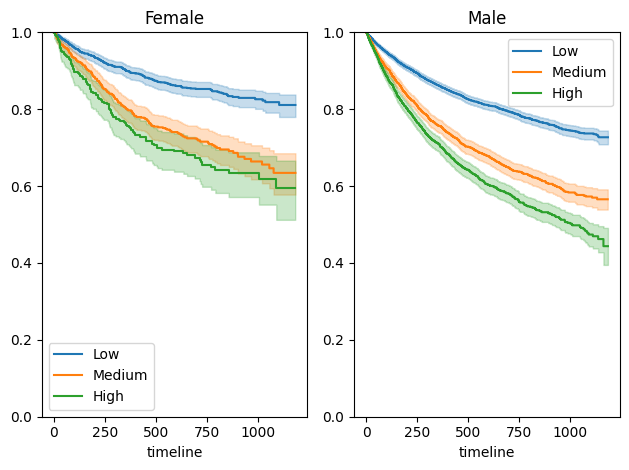

In [73]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = data[data["sex"] == "Female"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("Female")
axes[0].set_ylim(0, 1)

# Black chart
black = data[data["sex"] == "Male"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Male")
axes[1].set_ylim(0, 1)

# Show plots
plt.tight_layout()
plt.show()

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

#Individual Homework 2 - Coding: Explaining the COMPAS Replacement Model

The following code trains a model, appropriately split between test and train data, to run several transparency tests that evaluate the COMPAS Replacement Model's fairness. SHAP values, LIME, and counterfactuals are examined to assess whether there are biases in the model and if the model has discriminatory tendencies due to the data is trains itself on being inherently associated with systemic biases.

## Train/Test Split

Below we see a model being trained on 6 feautures: gender_factor, age_factor, race_factor, priors_count, crime_factor, and two_year_recid, all of which were used in the previous models above. Each feature is already cleaned up from earlier in the notebook, making it efficient to use in this case. Our target variable, the score_factor, evaluates whether individuals are high or low risk for recidivism. There is a train and test split present in this model, 20% of the data being put aside for test. Lastly, the shape of the train and test are printed for transparency. We see that in our trainign data, 4937 observations in the data are used, and 1235 are used in the test. Both sets have 6 features involved.

In [74]:
from sklearn.model_selection import train_test_split

# Create design matrix
X = df[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']]

# Define y using the 'score_factor' created in this cell
y = df['score_factor']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


After defining our train/test split of the data, the code below builds and trains two machine learning models, first by splitting the features into numeric and category types, transforming those features by either assigning dummy values (category) or standardization (numeric), creating a logistic regression, along with a black-box model. While the logistic regression is more interpretable, the black-box model has more predictive power. The purpose of using pipelines is to ensure reproducibility.  

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define features to be used
numeric_features = ['priors_count']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor', 'two_year_recid']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat",OneHotEncoder(
        handle_unknown="ignore"), category_features),
])

#Logistic Regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      random_state=42))
])
lr_pipeline.fit(X_train, y_train)

#Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

With the pipeline established, we can begin to analyze whether the model has discriminatory tendencies across different race groups. The code below produces two tables, one for logistic regression and the other for the black-box model, that shows each race's sample size, accuracy rate (% of group whose predicted score matched the actual score), false positive rate (% of the group who was predicted as high risk of recidivism but was actually low), false negative rate (% of the group who was predicted as low risk but was actually high), and AUC.

Several conclusions can be drawn from the table produced:


*   In either model, African-American indidivudals are 3-4x more likely to be falseley labeled as high-risk compared to Caucasian individuals. This signals a clear violation of FPR parity. Also, because this pattern is present in both models, it is clear this is a deeply rooted problem that is caused by the data (rather than model choice).
*   In either model, Caucasian defendants have a much higher false negative rate than African-American defendants, making the systematic unfairness two-fold: not only are African-Americans getting falsely accused, but White defendants who should be accused aren't.


*   Despite high accuracy values, the patterns above indicate that although the model may seem accurate, it can create different errors for different groups, leaving signficant impact and potential disparity.

With these conclusions, it is clear that a deeper examination into the relationships of the data must be conducted. Local Interpretable Model-agnostic Explanations (LIME) could be used to explain the predictions of these models, specifically the complex black-box model.

In [76]:
import pandas as pd
from sklearn.metrics import (confusion_matrix,
                            accuracy_score,
                            roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf['actual'], gdf['pred']
        ).ravel()
        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(
                gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


By selecting a Black and White defendant from the data, and conducting LIME for both observations, we can compare how each prediction came to be with the features in the model. If the feautures in the model signficantly differ in their contributions to the prediction, it could reveal discriminatory practices the model is inherently conducting.

From the LIME analysis, we can draw the following conclusions:


*   The predicted risk difference between the White and Black defendant is large. For the Black defendant, there is a predicted 59% chance of recidivism, whereas the White defendant has a 24% chance.

*  For the Black defendant, the biggest contributors are race and ages, which have noticeable impact. Although race contributes moderately, the positive contribution alone should be noted.
*   For the White defendant, not being African-American or Native American reduced the predicted risk for recidivism. Additionally, not being less than 25 reduced the predict risk, while not being greater than 45 increased the risk.

With these conclusions in mind, there is more evidence of a race effect that is present in the model, ultimately increasing the predicted risk values for Black defendants over White defendants. When looking specifically at race-factor, being African-American was a positive contributor to the predicted risk for Black defendants, and the opposite effect occured for White defendants for not being African-American. Additionally, the difference in the overall prediction supports the patterns seen in the group-level FPR disparities.





In [77]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
                     list(preprocessor
                          .named_transformers_['cat']
                          .get_feature_names_out(
                              category_features))),
    class_names = ["No Recid", "Recid"],
    mode = 'classification',
    discretize_continuous = True,
    random_state = 42
)

#Black and White defendant with predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Filter for African-American defendants before finding the middle index
black_df = X_test_copy[
    X_test_copy["race_factor"] == "African-American"
].sort_values('pred_prob')

# Find the middle index for the African-American defendants
black_idx = black_df.index[len(black_df) // 2]

# Filter for White defendants before finding the middle index
white_df = X_test_copy[
    X_test_copy["race_factor"] == "Caucasian"
].sort_values('pred_prob')

# Find the middle index for the White defendants
white_idx = white_df.index[len(white_df) // 2]

# Conduct LIME and print results
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn = gbt_pipeline['classifier'].predict_proba, num_features = 6
    )
    print(f"\n LIME: {label}")
    print(f"Predicted probability: "
        f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
      print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3368
 age_factor_Greater than 45 <= 0.00       +0.2173
 0.00 < race_factor_African-American <= 1.00 +0.1094
 -0.47 < priors_count <= 0.17             -0.0901
 race_factor_Hispanic <= 0.00             +0.0820
 two_year_recid_0 <= 0.00                 +0.0416

 LIME: White defendant
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4171
 age_factor_Less than 25 <= 0.00          -0.3528
 -0.68 < priors_count <= -0.47            -0.2735
 age_factor_Greater than 45 <= 0.00       +0.2316
 race_factor_African-American <= 0.00     -0.1128
 two_year_recid_1 <= 0.00                 -0.0448


After conducting LIME, SHAP can be used to explain the GBT model predictions. In this code, a global explanation is plotted across the dataset, and below that, other explanations for individual defendants (Black and White) are shown.

Starting globally, the beeswarn plot reveals what features impact the model's output for a specific data point. Anything to the right of the axis is contributing positively to the score (higher risk), and anything to the left of the axis is contributing negatively to the score (lower risk). We see that a high number of prior offenses overall pushes the risk prediction higher. Additionally, age dynamic play a big role in predictions, with being under 25 increases the predicted risk, and being over 45 decreasing the predicted risk. Looking at all of the races in the graph, the African-American feature is the most spread. This indicates that for some obversations, that feature increased risk (because they were Black), and for others, it decreased it (because they were not black).

When looking at SHAP more locally, between a White defendant and a Black defendant, we examine the waterfall chart below the first plot. This chart clearly visualizes what features contributed the most to the prediction, moving in either a positive direction (predicting higher risk) or negative direction (predicting lower risk). For the Black defendant, we see that their predicted risk is increased 0.3, whereas the White defendant for not being African-American has their predicted risk decreased by 0.28, showing the discrimination of the model firsthand. Additionally, we see that both defendants have negative contributions associated with the prior_counts feature, because their values are low (lower risk is therefore interpreted). However, the contribution value is stronger for the White defendant, meaning that a lower priors_count goes farther for predicted lower risk than for the Black defendants.

The Shapley values show that race and correlated features have a meaningful impact on the black-box model’s predictions, with African-American race increasing predicted risk and low priors_count reducing it to a lesser extent. This illustrates that, even in a black-box model, individual-level feature contributions reveal systematic disparities in predicted recidivism.

 99%|===================| 1227/1235 [00:16<00:00]       

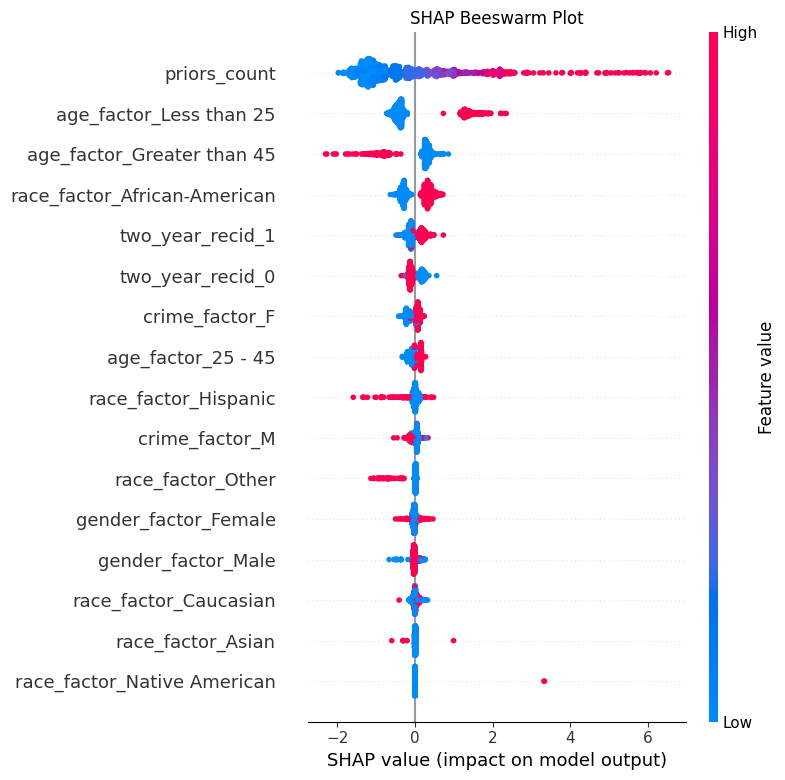

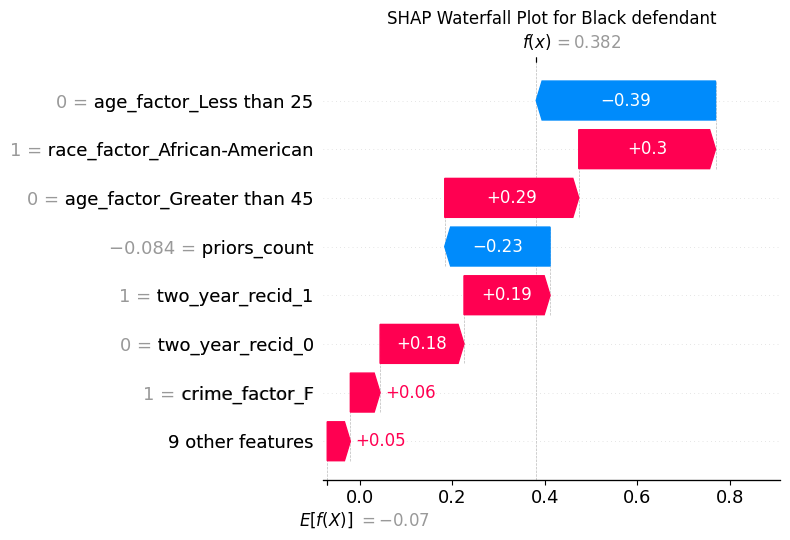

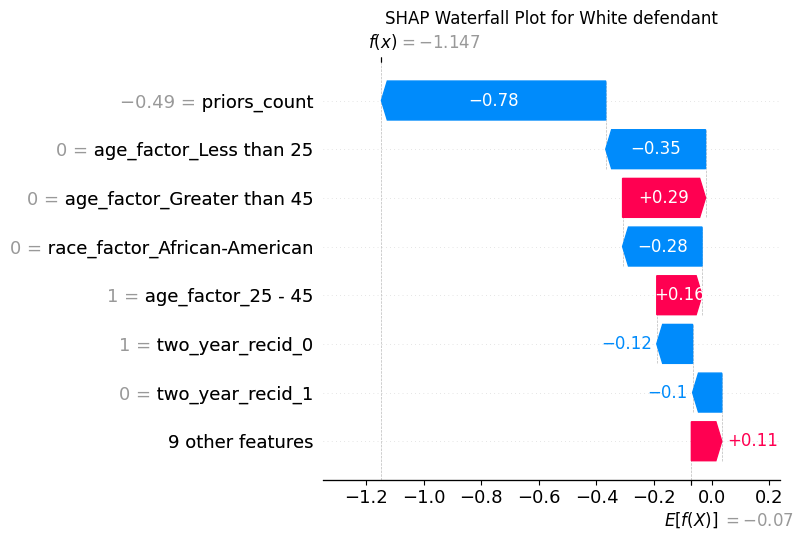

In [78]:
import shap
import matplotlib.pyplot as plt

#Prepare Test data for SHAP
X_test_enc = preprocessor.fit_transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_['cat']
                   .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline['classifier'],
    shap.maskers.Independent(X_test_enc, max_samples=100),
    feature_names = feat_names
)
shap_values = explainer_shap(X_test_enc)

#Global beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names,
                  show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()
plt.close()

#Waterfall plots for Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

for loc, label in [
    (black_loc, "Black defendant"),
    (white_loc, "White defendant")
]:
    plt.figure()
    shap.waterfall_plot(
        shap_values[loc],
        max_display = 8,
        show=False
    )
    plt.title(f"SHAP Waterfall Plot for {label}")
    plt.tight_layout()
    plt.show()
    plt.close()


Another transparency tool that can be used, going beyond LIME and SHAP, is Diverse Counterfactual Explanations (DiCE), which generates counterfactuals derived from the model to inform what features could be changed to receive a different output in the model. Not only does it help understand why a model makes the prediction it does, but explains what could have been predicted if the features were differently. This is useful for decision-making and also, establishing a basis for policy guidance to avoid discimrinatory models.



In [79]:
# Install dice_ml if not already installed
!pip install dice_ml

import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
  dataframe = pd.concat([X_train, y_train], axis=1),
  continuous_features = numeric_features,
  outcome_name = y.name
)
dice_model = dice_ml.Model(
  model = gbt_pipeline,
  backend = "sklearn",
  model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx),
                  ("White defendant", white_idx)]:
  query = X_test.loc[[idx]]
  cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {
        "priors_count": [0, 38],
        "age_factor": X_train['age_factor'].unique().tolist(),
        "crime_factor": X_train['crime_factor'].unique().tolist()
    },
    features_to_vary = ["age_factor", "priors_count",
                        "crime_factor"]
)
print(f"\n DiCE counterfactuals: {label} ")
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.50it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Male,25 - 45,Caucasian,1,F,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,Less than 25,-,8,-,0,1
1,-,Less than 25,-,20,-,0,1
2,-,-,-,33,M,0,1


##1. Compute SHAP values for your model on the test set. Produce beeswarm summary plot and a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

As described above, the beeswarm plot shows SHAP globally, whereas the waterfall plots are showing the feature contributions for the idnividual data point. In this case, below the beeswarm plot are four waterfall plots: one low-risk White defendant, one high-risk White defendant, one low-risk Black defendant, and one high-risk Black defendant. With all of these visuals, it becomes more apparent as to what biases the model may have that could be flagged as discriminatory and concerning.

Starting with the beeswarm plot, we see that the testing data plot is very similar to the training data plot shown above. Prior counts are a major contributor to higher predicted risk (as more counts are received, the higher the risk an individual is for recidivism). Additioanlly, we see that the African-American feature is divided. The blue (low values, so the individuals who are not African-American) see a decrease in predicted risk, whereas the red (high values, so Black defendants) see an increase in predicted risk, reflecting the pattern shown in the FPR and FNR differences in the previous outputs above. We can also see that those who are less than 25 received a higher predicted risk, whereas those who are greater than 45 are less likely to receive a high risk score. Also, those who are between 25-45 see a slightly increase in predicted risk. Gender does not seem to play as a huge influence among the other features in the model, along with crime factor.

Looking at the waterfall plots, many conclusions can be drawn:

For one, the White defendant needs a very high prior count value to achieve a high score in comparison to the Black defendant. The ratio is 1.85:1 for the high-risk Black defendant, whereas the ratio is 0.99:1 for the high-risk White defendant. This suggest that the model is weighing the prior counts for the Black defendant more than the White defendant, which is discriminatory. We also see that the high-risk White defendant has less of a predicted risk because they are not African-American (-0.35), meanwhile, there is an increased prediction of risk because the Black defendant is African-American (+0.7, concerning, as this is more weighted).

Secondly, looking at the low-risk defendants across the two races, we see the lowest risk value for the White defendants is -4.04, whereas Black defendants have the lowest risk of -3.84. We see on the two charts that despite having equal benefits from being over 45 years-old and having a low prior count value, there is still a penalty for being African-American for the Black defendant, whereas for the White defendant, not being African-American acts as a bonus (-0.29). This enabled the Black defendants total risk score to be slightly higher in the end, despire similar profiles.

Through these charts, it is shown that the model doesn't simply consider race, but applies it as a weighted penalty against Black defendants regardless of similar profiles to White defendants.

 96%|=================== | 1181/1235 [00:16<00:00]       

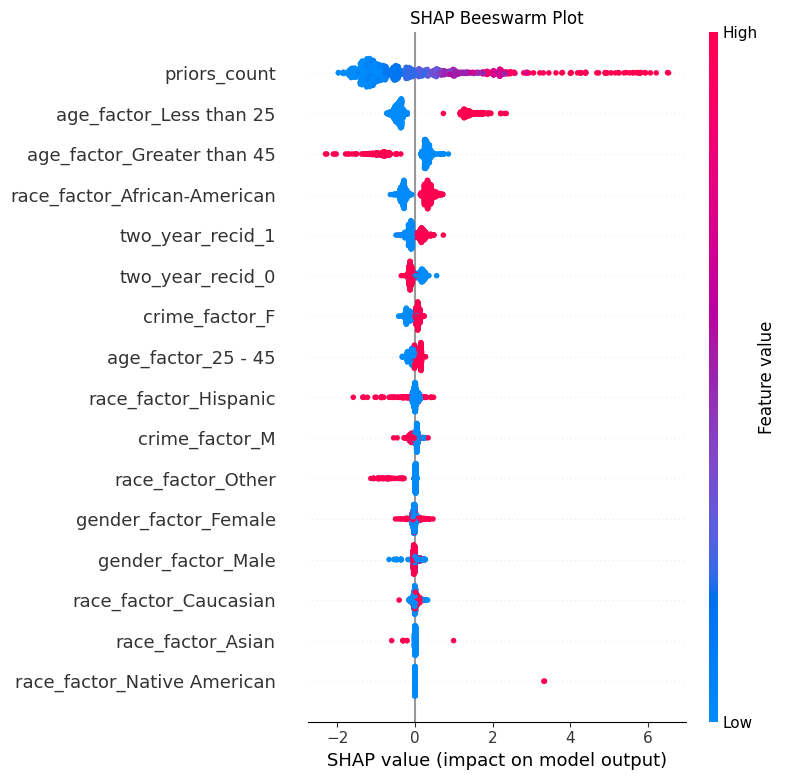

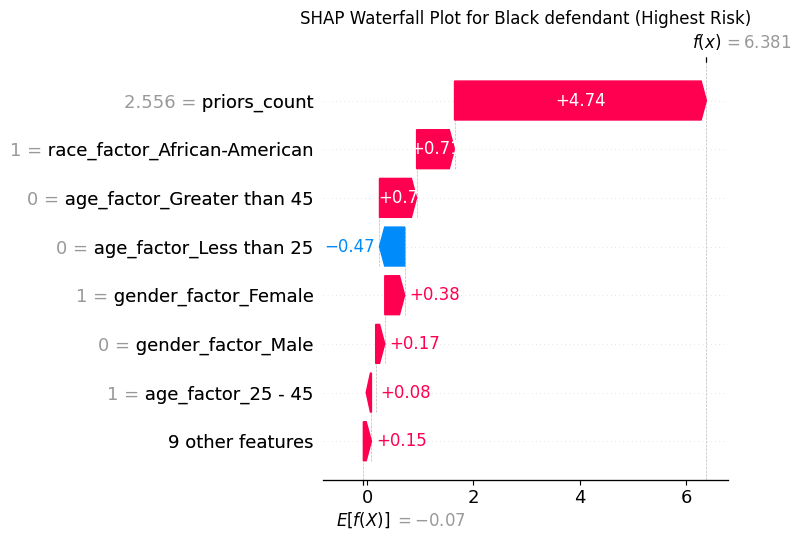

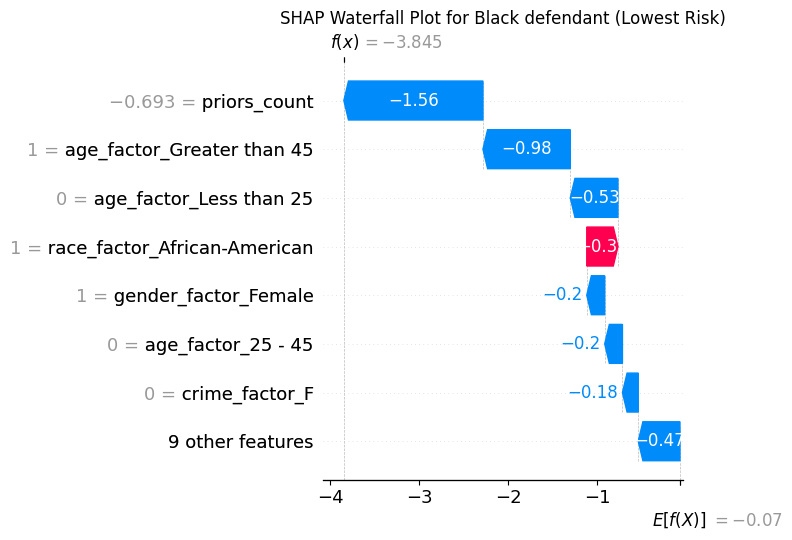

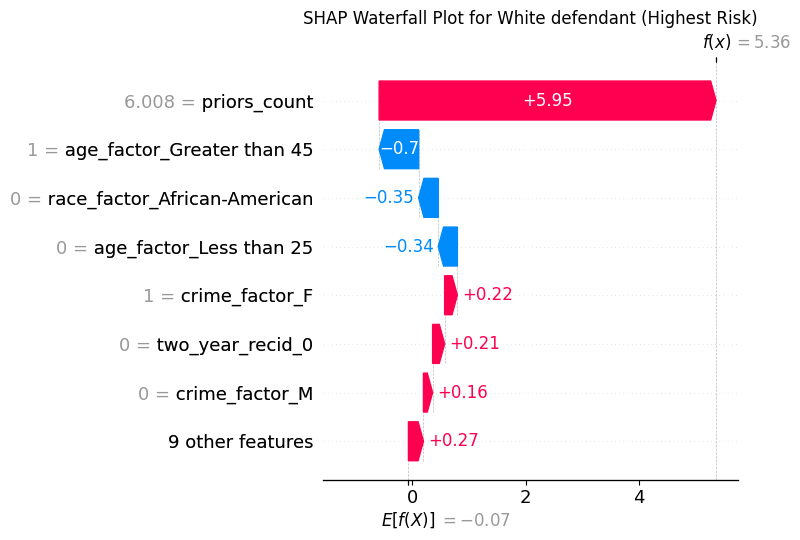

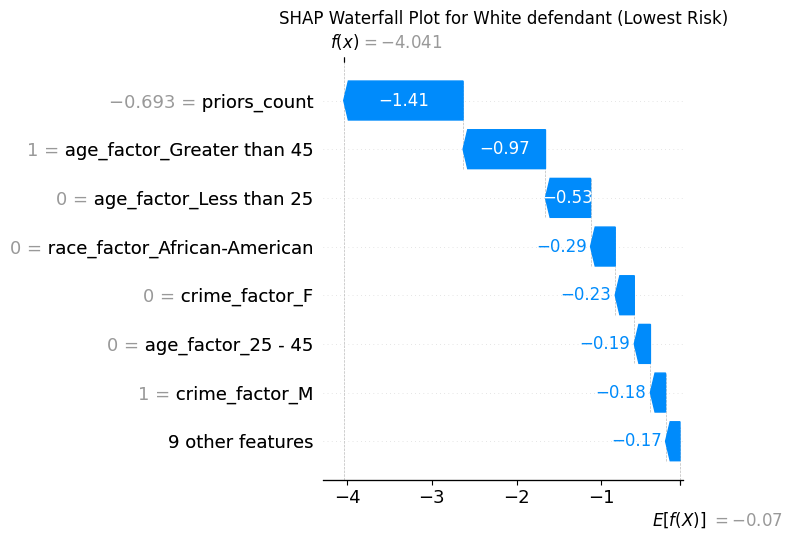

In [80]:
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.fit_transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_['cat']
                   .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline['classifier'],
    shap.maskers.Independent(X_test_enc, max_samples=100),
    feature_names = feat_names
)
shap_values = explainer_shap(X_test_enc)

#Global beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names,
                  show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()
plt.close()

# Select the highest and lowest risk Black and White defendants
# Filter for African-American defendants and sort by predicted probability
black_df_sorted = X_test_copy[
    X_test_copy["race_factor"] == "African-American"
].sort_values('pred_prob')

# Get indices for highest and lowest risk Black defendants
black_highest_risk_idx = black_df_sorted.index[-1]
black_lowest_risk_idx = black_df_sorted.index[0]

# Filter for Caucasian defendants and sort by predicted probability
white_df_sorted = X_test_copy[
    X_test_copy["race_factor"] == "Caucasian"
].sort_values('pred_prob')

# Get indices for highest and lowest risk White defendants
white_highest_risk_idx = white_df_sorted.index[-1]
white_lowest_risk_idx = white_df_sorted.index[0]

# Waterfall plots for selected defendants
for label, idx in [
    ("Black defendant (Highest Risk)", black_highest_risk_idx),
    ("Black defendant (Lowest Risk)", black_lowest_risk_idx),
    ("White defendant (Highest Risk)", white_highest_risk_idx),
    ("White defendant (Lowest Risk)", white_lowest_risk_idx)
]:
    loc = X_test.index.get_loc(idx)
    plt.figure()
    shap.waterfall_plot(
        shap_values[loc],
        max_display = 8,
        show=False
    )
    plt.title(f"SHAP Waterfall Plot for {label}")
    plt.tight_layout()
    plt.show()
    plt.close()

## 2. Run LIME on the same four individuals. Compare LIME and SHAPE feature attributions

Running LIME provides a local look at how the model justifies its decision for the four individuals being examines (a combination of low-risk and high-risk Black and White defendants). This can be complementary to SHAP, seeing if the model is consistent.

1.   **Where do they agree?**

*   Across all four profiles, we see that a high prior count is a main contributor to the higher risk score. Alternatively, having a lower prior count decreased the chances, but was not as strong of a contributor as it is when the value is high.
*   The behaviors of age, specifically, being under 25-years-old, was aligned across all four profiles. Those who are not under 25-years-old are less risky according to the model. Since none of the observations are under 25, each individual, despite risk or race, saw a descrease in predicted race by approximately -0.3.

2.  **Where do they diverge?**


*   Black defendants, regardless of being high-risk or low-risk, receive a penalty (get a higher predicted risk score) because they are African-American. Both Black defendants saw a +0.11 increase in predicted score. So, even the least-risky African-American defendent is seen as more of a threat because of their race. Alternatively, White defendants are given a negative weight because they are not African-American (-0.1). This shows that despite any risk, White defendants are seen as less of a risk because they are not African-American.


3.   What does divergence imply for governance?


*   The main divergence listed implies a lack of recourse. If you are African-American, you cannot change your race to improve their score. Instead, they face a penalty that can't be erased from the model if they change something, making the model extremely biased and not suitable for high-stakes setting such as lending or criminal justice.
*   We see with both LIME and SHAPE that the bias is not an outlier or because its evaluating a particular case in the data. Instead, we can see that these discirminatory tendencies of the model are because of the architecture of the model and the data it trains on. Governance bodies should flag this model as high risk, as it fails to be fair and unbiased in making predictive outcomes.





In [81]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

#Prepare data for LIME
X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
                     list(preprocessor
                          .named_transformers_['cat']
                          .get_feature_names_out(
                              category_features))),
    class_names = ["No Recid", "Recid"],
    mode = 'classification',
    discretize_continuous = True,
    random_state = 42
)

# Select the highest and lowest risk Black and White defendants from the previous step
# (Assuming black_highest_risk_idx, black_lowest_risk_idx, white_highest_risk_idx, white_lowest_risk_idx are already defined)

for label, idx in [
    ("Black defendant (Highest Risk)", black_highest_risk_idx),
    ("Black defendant (Lowest Risk)", black_lowest_risk_idx),
    ("White defendant (Highest Risk)", white_highest_risk_idx),
    ("White defendant (Lowest Risk)", white_lowest_risk_idx)
]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn = gbt_pipeline['classifier'].predict_proba, num_features = 6
    )
    print(f"\n LIME: {label}")
    print(f"Predicted probability: "
        f"{X_test_copy.loc[idx, 'pred_prob']:.3f}")
    for feat, weight in exp.as_list():
      print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant (Highest Risk)
Predicted probability: 0.999
 priors_count > 0.17                      +0.3886
 age_factor_Less than 25 <= 0.00          -0.3432
 age_factor_Greater than 45 <= 0.00       +0.2162
 0.00 < race_factor_African-American <= 1.00 +0.1131
 two_year_recid_1 <= 0.00                 -0.0464
 0.00 < two_year_recid_0 <= 1.00          -0.0416

 LIME: Black defendant (Lowest Risk)
Predicted probability: 0.021
 race_factor_Native American <= 0.00      -0.4289
 age_factor_Less than 25 <= 0.00          -0.3525
 age_factor_Greater than 45 > 0.00        -0.2260
 0.00 < race_factor_African-American <= 1.00 +0.1168
 race_factor_Hispanic <= 0.00             +0.0903
 priors_count <= -0.68                    -0.0668

 LIME: White defendant (Highest Risk)
Predicted probability: 0.995
 race_factor_Native American <= 0.00      -0.4123
 priors_count > 0.17                      +0.3777
 age_factor_Less than 25 <= 0.00          -0.3342
 age_factor_Greater than 45 > 0.00       

##3. Generate at least one counterfactual per individual using DiCE. Report the minimal feature changes required to flip the prediction. Flag counterfactuals that require changes to immutable features.

DiCE provides the shortest path to a different prediction outcome, making it a useful tool to not only show what the model predicts, but *how* it can predict differently. When identifying biases in the model that are discriminatory, this tool can be useful to determine if the model suggests logical changes rather than changing immutable traits (such as race) to alter the outcome.

Below is a description of each counterfactual produced for the four individuals being discussed:



*   **High-Risk White Defendant:** With the original outcome of 1, there are a couple of ways the high-risk White defendant can alter the outcome to be 0. The defendant is a male, who is older than 45, has a prior_count of 33, and a crime factor of F (felony). With the prior counts being the main driver of the predicted outcome of 1, all of the counterfactuals suggest decreasing the prior counts. Additionally, having M as a crime factor (misdemeanor), would alter the prediction to be 0 (on top of decreasing prior counts). In this case, the minimal feature change would be to decrease prior counts (and change outcome for two_year_recid).

*   **Low-Risk White Defendant:** With the original outcome of 0, the low-risk White defendant can later the outcome to 1 by changing their age to be less than 25, and increase prior count. Since the model assigns a higher risk to those who are less than 25 years-old, the quickest way for White defendents to be perceived as high risk is to change their age. However, this is an immutable feature, which should be flagged. This defendant cannot change their age. Additionally, CF changed for the last counterfactual. Regardless, the minimal feature change would be to decrease age, and increase prior count.


*   **High-Risk Black Defendant:** With the original outcome of 1, the high-risk Black defendant can change their outcome by getting older and also reducing their prior count. However, it is important to note that the high-risk black defendent only has a prior count of 16, whereas the highest-risk White defendant has a prior count of 33. In this case, the minimal feature change for this defendant would be to decrease the prior count to 2 (no getting older past 45 is needed). This is another identifier that there is bias toward Black defendants. To be granted a score of 0, 1-3 prior counts are needed, whereas White defendants get the same score with a prior count of 4-19

*   **Low-Risk Black Defendant:** With the original outcome of 0, the low-risk Black defendant, who is a female that is older than 45 and has no prior counts, can change their outcome by being in the 25-45 age range (an immutable feature, as one cannot become younger), and by increasing prior count dramatically. The minimal feature change in this case would be increases the prior count from 0 to 21.

While we see that race was not a required feature that needed to be changed, it does not mean that the model is not biased or that race is not influence the prediction outcomes. DiCE only looks at local explanations, and in these specific, extreme examples, race was not apart of hte counterfactual directly, but could still be indirectly related as it could be correlated to features like prior count.

In [82]:
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
  dataframe = pd.concat([X_train, y_train], axis=1),
  continuous_features = numeric_features,
  outcome_name = y.name
)
dice_model = dice_ml.Model(
  model = gbt_pipeline,
  backend = "sklearn",
  model_type = "classifier"
)

#Create DiCE explainer object
exp_dice = Dice(dice_data, dice_model, method="random")

#Loop over each defendant being assessed in this case and print counterfactuals
for label, idx in [
    ("Black defendant (Highest Risk)", black_highest_risk_idx),
    ("Black defendant (Lowest Risk)", black_lowest_risk_idx),
    ("White defendant (Highest Risk)", white_highest_risk_idx),
    ("White defendant (Lowest Risk)", white_lowest_risk_idx)
]:
  query = X_test.loc[[idx]]
  cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {
        "priors_count": [0, 38],
        "age_factor": X_train['age_factor'].unique().tolist(),
        "crime_factor": X_train['crime_factor'].unique().tolist()
    },
    features_to_vary = ["age_factor", "priors_count",
                        "crime_factor"]
)
  print(f"\n DiCE counterfactuals: {label} ")
  cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


 DiCE counterfactuals: Black defendant (Highest Risk) 
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Female,25 - 45,African-American,16,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,-,-,2,M,0,0
1,-,Greater than 45,-,4,-,0,0
2,-,Greater than 45,-,0,-,0,0


...

100%|██████████| 1/1 [00:00<00:00,  3.31it/s]


 DiCE counterfactuals: White defendant (Lowest Risk) 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Female,Greater than 45,Caucasian,0,M,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,Less than 25,-,28,-,0,1
1,-,-,-,20,-,0,1
2,-,-,-,18,F,0,1


#Individual Homework 3 - Disparate Impact Audit

### Step 0: Setup and imports

Before starting the disparate impact audit, the first step is to defined a new variable, "high-risk", which indicates whether an observation in the dataset has a decile score of 7 or more. This was then used to measure AIR, ME, and SMD.

In [83]:
# !pip install solas-ai
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd
# Load and clean COMPAS data (Lecture 01 pipeline)
df['high_risk'] = (df['decile_score'] >= 7).astype(int)
print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          0              1


First, to see if there is a significant difference in AIR between Black and White defendants, a two-proportion z-test can be conducted. Since the p-value is less than 0.05, we can see that further investigation needs to be done to identify disparate impact.

In [84]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 16.827, p = 0.0000


##1. Compute AIR, ME, and SMD for race and sex separately using the solas-ai Python library. Confirm both produce identical results

Computer AIR, ME, and SMD for race and sex separately using the Solas AI Python library requires pandas, pathlib, and solar_disparity. Once those are acquired and in the environment, we can first asses race's metric, then sex to reveal patterns in the data. The AIR determines whether one group is being selected (or flagged as high risk) at a lower rate than another. Additionally, SMD reveals Wwether different groups are receiving systematically higher or lower risk scores. Lastly, ME shows how much changing a feature changes the predicted outcome.

In [85]:
import pandas as pd
from pathlib import Path
from warnings import simplefilter
simplefilter("ignore")
import solas_disparity as sd

### Race AIR and SMD Using SolasAI

In order for SolasAI to take into account the different races accurately, boolean variables need ot be set up for each observation that indicates what race the individual is in separate columns. To do this, new columns were created, such as "is_African-American", and when this was done, we could define the protected groups, reference groups, and group categories. Those in the protective group are variables or attributes of the model that should not be changed or effect outcomes, as that is a sign of discrimination. To pair with that, the reference group is what the Solas AI tests refer to, in this case, it's the Caucasian race. Lastly, the group categories specifies what type of variables are in the two groups.

In [86]:
# Encode race categories into binary
race_dummies = pd.get_dummies(df['race'], prefix='is').astype(int)

# Attach these indicators
df = pd.concat([df, race_dummies], axis=1)

print("df with Racial Indicators:")
display(df[['race'] + race_dummies.columns.tolist()].head(10))

df with Racial Indicators:


,race,is_African-American,is_Asian,is_Caucasian,is_Hispanic,is_Native American,is_Other
0,Other,0,0,0,0,0,1
1,African-American,1,0,0,0,0,0
2,African-American,1,0,0,0,0,0
5,Other,0,0,0,0,0,1
6,Caucasian,0,0,1,0,0,0
7,Other,0,0,0,0,0,1
8,Caucasian,0,0,1,0,0,0
10,Caucasian,0,0,1,0,0,0
11,African-American,1,0,0,0,0,0
12,Caucasian,0,0,1,0,0,0


In [87]:
protected_groups = ["is_African-American", "is_Asian", "is_Native American", "is_Hispanic", "is_Other"]
reference_groups = ["is_Caucasian", "is_Caucasian", "is_Caucasian", "is_Caucasian", "is_Caucasian"]
group_categories = ["race", "race", "race", "race", "race"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_African-American', 'is_Asian', 'is_Native American', 'is_Hispanic', 'is_Other']
Reference Groups: ['is_Caucasian', 'is_Caucasian', 'is_Caucasian', 'is_Caucasian', 'is_Caucasian']
Group Categories: ['race', 'race', 'race', 'race', 'race']


With the groups and categories specified, we can run the sd.adverse_impact_ratio function to reveal whether any of the races have an AIR below 0.8, because this would provide evidence of disparate impact due to the model. However, one thing that is required is to flip the outcome specified in the model to be those who are not labeled as high_risk, as opposed to those who are. If we specified the outcome as "high_risk", we would not be measuring how much more likely a race group is to being labeled as high risk relative to the White defendants, but we would be measuring how more more likely a race group is to being labeles as low risk relative to them. To ensure we are using the bases that the AIR has to be below 0.8, the outcome needed to be flipped.

When that was accomplished, it was revealed that both African Americans and Native Americans are below the 0.8 threshold that is commonly used and frequently advised by the EEOC. This means that Black and Native American defendants are more likely to be labeled as high-risk than White defendants, leaving evidence of disparate impact to consider.

Additionally, when looking at ME of -0.214, we can see that African-American defendants are, on average, 21.4% less likely to receive a "Low Risk" classificaiton than Caucasian defendants, which is the ideal, favorable outcome. Same goes for Native Americans, who are 38.5% less likely to receive a "Low Risk" classification than White defendants.

In [88]:
from IPython.display import display

# Invert high_risk so that 1 = Favorable (Not High Risk)
favorable_outcome_series = (df["high_risk"] == 0).astype(int)

air = sd.adverse_impact_ratio(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=favorable_outcome_series,
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0,
)
display(air.summary_table)

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_African-American,is_Caucasian,race,6172,0.0,3175,1987,0.625827,0.214401,0.744829,2.598543e-63,Yes,680.724679
is_Asian,is_Caucasian,race,6172,0.0,31,27,0.870968,-0.030739,1.036585,8.071686e-01,No,NaN
is_Native American,is_Caucasian,race,6172,0.0,11,5,0.454545,0.385683,0.540979,3.847356e-03,Yes,4.242511
is_Hispanic,is_Caucasian,race,6172,0.0,509,434,0.852652,-0.012424,1.014786,5.415250e-01,No,NaN
is_Other,is_Caucasian,race,6172,0.0,343,312,0.909621,-0.069393,1.082588,5.857760e-04,No,NaN
is_Caucasian,,race,6172,0.0,2103,1767,0.840228,NaN,NaN,NaN,,NaN


To ensure Solas AI was correctly, the code from Lecture 03 was repurposed and used for comparison. As it turns out, Solas AI was correct in indentifying the AIR for groups relative to the Caucasian reference group. It reveals that Native american and African-American groups are less likely to be identified as low risk, and therefore, are more likely to be identified as high risk, raising concern for disparate impact.

In [89]:
def selection_rate_low_risk(df, group_col, outcome_col, ref_group):
  """Selection rates for Low Risk (high_risk=0), AIR, and ME relative to reference group"""
  # Create a temporary column where 1 = Low Risk, the favorable outcome
  df_temp = df.copy()
  df_temp['low_risk_outcome'] = (df_temp[outcome_col] == 0).astype(int)

  rates = (df_temp.groupby(group_col)['low_risk_outcome'].mean().rename('low_risk_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'low_risk_rate'].values[0]

  # AIR
  rates['AIR'] = rates['low_risk_rate'] / ref_rate
  rates['ME'] = rates['low_risk_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates

sir = selection_rate_low_risk(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  low_risk_rate      AIR        ME        flag_80
 Native American       0.454545 0.540979 -0.385683 *** BELOW 0.80
African-American       0.625827 0.744829 -0.214401 *** BELOW 0.80
       Caucasian       0.840228 1.000000  0.000000               
        Hispanic       0.852652 1.014786  0.012424               
           Asian       0.870968 1.036585  0.030739               
           Other       0.909621 1.082588  0.069393               


SMD reveals further evidence of disparate impact by comparing the average predicted score or risk between a protected group and a reference group, relative to the variability in scores. While an SMD close to 0 indicates that the groups have similar average scores and minimal disparity, those farther away from zero indicate that the predicted group either tends to have a higher score (SMD > 0) or a lower score (SMD < 0) than the reference group. In this sense, we use decile_score because this measure is for continuous variables, not binary indicators. The results are shown below.

In [90]:
smd = sd.standardized_mean_difference(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df["decile_score"],
    smd_threshold=30,
    lower_score_favorable=True
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_African-American,is_Caucasian,race,6172,0.0,3175,5.276850,1.641567,2.839463,57.812597,1.072010e-97,Yes
is_Asian,is_Caucasian,race,6172,0.0,31,2.838710,-0.796573,2.839463,-28.053656,8.597731e-02,No
is_Native American,is_Caucasian,race,6172,0.0,11,6.454545,2.819263,2.839463,99.288571,2.837387e-04,Yes
is_Hispanic,is_Caucasian,race,6172,0.0,509,3.383104,-0.252179,2.839463,-8.881214,4.617866e-02,No
is_Other,is_Caucasian,race,6172,0.0,343,2.889213,-0.746070,2.839463,-26.275040,4.573581e-07,No
is_Caucasian,,race,6172,0.0,2103,3.635283,NaN,2.839463,NaN,NaN,


Although the SMD's in the Solas AI version are slightly off from the code used in Lecture 03, there are similar values to interpret. Also, note that the SMD values in the Solas AI version are multiplied by 100 to be shown as integers, whereas the code below shows SMD values are decimals.

Regardless, we see that, relative to the White defendants, Native American and African-American defendants has a very large and large (respectively), indicating that risk scores for these two racial groups are shifted significantly higher than the White defendants. On average, these two racial groups receive decile scores that are 1.008 (Native American) or 0.608 (African-American) standard deviations higher than White defendants.

In [91]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
    sc = g[score_col]
    pooled = np.sqrt((ref.var() + sc.var()) / 2)
    d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
    mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
    results.append({
      group_col: grp,
      'mean_score': round(sc.mean(), 3),
      'SMD': round(d, 3),
      'magnitude': mag
    })
  return pd.DataFrame(results)

smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


##Gender AIR and SMD using SolasAI

Now to repreat the process for Gender, we first need to make dummy variables that indicate whether each observation is female or male. When this is done, we can then define our protected group (female), reference group (male), and group categories (sex).

In [92]:
# Encode race categories into binary
race_dummies = pd.get_dummies(df['sex'], prefix='is').astype(int)

# Attach these indicators
df = pd.concat([df, race_dummies], axis=1)

print("df with Gender Indicators:")
display(df[['sex'] + race_dummies.columns.tolist()].head(10))

df with Gender Indicators:


,sex,is_Female,is_Male
0,Male,0,1
1,Male,0,1
2,Male,0,1
5,Male,0,1
6,Male,0,1
7,Male,0,1
8,Female,1,0
10,Male,0,1
11,Male,0,1
12,Female,1,0


In [93]:
protected_groups = ["is_Female"]
reference_groups = ["is_Male"]
group_categories = ["sex"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_Female']
Reference Groups: ['is_Male']
Group Categories: ['sex']


Now that out protected group, reference group, and group category is defined, we can now run the sd.adverse_impact_ratio to function to reveal whether females, with reference group being males, are more or less likely to be assigned as low risk and in turn, if there are more or less likely to be assigned as high risk relative to males in the data. Below are the outputs: one from Solas AI and one from a repurposed code from Lecture 3.

In [94]:
from IPython.display import display

# Invert high_risk so that 1 = Favorable
favorable_outcome_series = (df["high_risk"] == 0).astype(int)

air = sd.adverse_impact_ratio(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=favorable_outcome_series,
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0,
)
air.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Female,is_Male,sex,6172,0.0,1175,940,0.800000,-0.081169,1.112918,1.791485e-08,No,NaN
is_Male,,sex,6172,0.0,4997,3592,0.718831,NaN,NaN,NaN,,NaN


We see that relative to males, the AIR (females/males) does not fall below 0.8, a commonly used threshold upheld by the EEOC. Therefore, this metric does not show disparate impact affecting the protected group of females. In fact, the AIR value shows that females are actually more likely to be assigned as low_risk relative to males. This means that males are more likely to be labeled as high risk for recidivism. This is further supported by the ME interpretation, indciating that females are 8% more likely to be assigned the Low Risk classification relative to males in the model.

In [96]:
def selection_rate_low_risk(df, group_col, outcome_col, ref_group):
  """Selection rates for Low Risk (high_risk=0), AIR, and ME relative to reference group"""
  # Create a temporary column where 1 = Low Risk, the favorable outcome
  df_sex = df.copy()
  df_sex['low_risk_outcome'] = (df_sex[outcome_col] == 0).astype(int)

  rates = (df_sex.groupby(group_col)['low_risk_outcome'].mean().rename('low_risk_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'low_risk_rate'].values[0]

  rates['AIR'] = rates['low_risk_rate'] / ref_rate
  rates['ME'] = rates['low_risk_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates

sir = selection_rate_low_risk(df, 'sex', 'high_risk', ref_group='Male')
print(sir.sort_values('AIR').to_string(index=False))

   sex  low_risk_rate      AIR       ME flag_80
  Male       0.718831 1.000000 0.000000        
Female       0.800000 1.112918 0.081169        


With both the AIR and ME both examined and interpreted, the SMD should also be looked at to determine the statistical magnitude of the disparity between the two sexes. This is done using decile score, the continuous variable (rather than the binary indicator) to gain a broader persepctive on the effects of potential disparities. As a result, we see that the magnitutde is small. This indicates that the distributions of the two sexes are similar and have overlap. The protected group, females, is only 0.2 standard deviations away from the mean of the reference group (males).

In [97]:
smd = sd.standardized_mean_difference(
    group_data=df,  # dataset containing the protected and reference group information
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df["decile_score"],
    smd_threshold=30,
    lower_score_favorable=True
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,6172,0.0,1175,4.063830,-0.438071,2.839463,-15.427963,0.000002,No
is_Male,,sex,6172,0.0,4997,4.501901,NaN,2.839463,NaN,NaN,


The code below is a repurposed version of the code from Lecture 03 and used as a reference to determine if Solas AI was correct in calculating SMD. Although Solas AI multiplies the values by 100, the values are nearly identical, verifiying the accuracy of the Solas AI calculations.

In [98]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
    sc = g[score_col]
    pooled = np.sqrt((ref.var() + sc.var()) / 2)
    d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
    mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
    results.append({
      group_col: grp,
      'mean_score': round(sc.mean(), 3),
      'SMD': round(d, 3),
      'magnitude': mag
    })
  return pd.DataFrame(results)

smd_tbl = smd(df, 'sex', 'decile_score', ref_group='Male')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


##2. Build an intersectional analysis (race × sex). Report the worst-group AIR and interpret it.

To build the an intersectional analysis, we first combine race and sex into a single subgroup column to identify specific demographic combinations. Then, we filter the data to only include the combinations that have at least 30 observations so that the results are statistically sound. The script then sets "Caucasian / Male" as the reference baseline and creates binary indicator variables for all other valid intersectional groups. Using the solas_disparity library, it calculates the AIR for these groups based on the "high_risk" outcome. Finally, it displays a summary table sorted by impact and identifies the specific intersectional group facing the highest level of relative disparity.

In [99]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column
df['subgroup'] = df['race'].astype(str) + " / " + df['sex'].astype(str)

# Filter for combinations that only have an n of 30 or more
counts = df['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df[df['subgroup'].isin(valid_subgroups)].copy()

# Identify the protected and reference groups for the analysis
protected_intersections = [g for g in valid_subgroups if g != 'Caucasian / Male']

#Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (df_filtered_solasai['subgroup'] == group).astype(int)

# Invert high_risk so that 1 = Favorable (Not High Risk)
favorable_outcome_series = (df_filtered_solasai["high_risk"] == 0).astype(int)

#Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=["is_Caucasian / Male"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=favorable_outcome_series,
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']
print(f"\nThe intersectional group (n>=30) with the worst AIR is {worst_group_idx} at {worst_air:.3f}.")

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_African-American / Male,is_Caucasian / Male,subgroup,6130,0.0,2626,1586,0.603960,0.237495,0.717756,1.148046e-59,Yes,623.663171
is_African-American / Female,is_Caucasian / Male,subgroup,6130,0.0,549,401,0.730419,0.111037,0.868042,1.143445e-08,No,NaN
is_Hispanic / Male,is_Caucasian / Male,subgroup,6130,0.0,427,354,0.829040,0.012416,0.985245,5.540001e-01,No,NaN
is_Caucasian / Female,is_Caucasian / Male,subgroup,6130,0.0,482,403,0.836100,0.005356,0.993634,7.772631e-01,No,NaN
is_Other / Male,is_Caucasian / Male,subgroup,6130,0.0,285,258,0.905263,-0.063807,1.075830,5.002004e-03,No,NaN
is_Other / Female,is_Caucasian / Male,subgroup,6130,0.0,58,54,0.931034,-0.089579,1.106457,6.578450e-02,No,NaN
is_Hispanic / Female,is_Caucasian / Male,subgroup,6130,0.0,82,80,0.975610,-0.134154,1.159431,2.149889e-04,No,NaN
is_Caucasian / Male,,subgroup,6130,0.0,1621,1364,0.841456,NaN,NaN,NaN,,NaN



The intersectional group (n>=30) with the worst AIR is is_African-American / Male at 0.718.


With the output below and above, we see that when we conduct an intersectional analysis between the significant combinations of racial group and gender, only one combination is below the 0.8 threshold: African-American Males. This makes sense, as this group, which has larger than 30 observations, had been seen to be below the AIR threshold separately. When combined, it makes sense to also be facing the same issue. This particular value indicates that African-American men are only 71.8% to be labaled as low risk, the favorable outcome, as Caucasian men. This is well below the threshold for fairness, and provides evidence for disparate impact again Black defendants.

We see that only 60.4% of Black defendants received a favorable score, whereas 84.1% of White defendants received a favorable score.

We also see some reverse disparity occuring. Hispanic females and Other females are more likely to receive a favorable outcome than White males. This, and along with the other groups who exceed the 0.8 threshold, suggest that the model's primary source of bias is toward African-American men.

In [102]:
# Create a temporary column where 1 = Low Risk, the favorable outcome
df_intersection = df.copy()
df_intersection['low_risk_outcome'] = (df_intersection['high_risk'] == 0).astype(int)

# Intersectional analysis
df_intersection['subgroup'] = df_intersection['race'].astype(str) + ' / ' + df_intersection['sex'].astype(str)

# Keep subgroups with n >= 30 to reduce variance and make results statistically sound
counts = df_intersection['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df_intersection[df_intersection['subgroup'].isin(valid_sg)].copy()

# Calculate selection rates based on the favorable (low_risk) outcome
sub_rates = (df_sub.groupby('subgroup')['low_risk_outcome'].agg(['mean','count']).rename(columns={'mean':'low_risk_rate','count':'n'}).reset_index())

# Set reference rate based on Caucasian males
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','low_risk_rate'].values[0]
sub_rates['AIR'] = sub_rates['low_risk_rate'] / ref_rate
sub_rates['ME'] = sub_rates['low_risk_rate'] - ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print(sub_rates.sort_values('AIR').to_string(index=False))

worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst Intersectional Group (Favorable=Low Risk): {worst['subgroup']}, AIR={worst['AIR']:.3f} and n={worst['n']}")

                 subgroup  low_risk_rate    n      AIR        ME           flag
  African-American / Male       0.603960 2626 0.717756 -0.237495 *** BELOW 0.80
African-American / Female       0.730419  549 0.868042 -0.111037               
          Hispanic / Male       0.829040  427 0.985245 -0.012416               
       Caucasian / Female       0.836100  482 0.993634 -0.005356               
         Caucasian / Male       0.841456 1621 1.000000  0.000000               
             Other / Male       0.905263  285 1.075830  0.063807               
           Other / Female       0.931034   58 1.106457  0.089579               
        Hispanic / Female       0.975610   82 1.159431  0.134154               

Worst Intersectional Group (Favorable=Low Risk): African-American / Male, AIR=0.718 and n=2626


## 3. Compute FPR and FNR disparities by race. Test statistical significance with a two-proportion z-test

To compute FPR and FNR disparities by race, we first have to calculate  the False Positive Rate, identifying if innocent people in protected groups are labeled "High Risk" more often than Caucasians. Then, we find the False Negative Rate, checking if people who actually re-offended are being labeled "Low Risk" more often for certain groups than others. Both of these rates will reveal to us the fairness of the model's mistakes by comparing them to different racial groups who are wrongly categorized. If we see significant differences, this violates equualized odds, which would provide evidence that disparate impact is present.

In [103]:
fpr_disparity = sd.false_positive_rate(
    group_data=df,
    protected_groups=["is_African-American", "is_Asian", "is_Native American", "is_Hispanic", "is_Other"],
    reference_groups=["is_Caucasian"] * 5,
    group_categories=["race"] * 5,
    outcome=df["high_risk"].astype(int),
    label=df["two_year_recid"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

fnr_disparity = sd.false_negative_rate(
    group_data=df,
    protected_groups=["is_African-American", "is_Asian", "is_Native American", "is_Hispanic", "is_Other"],
    reference_groups=["is_Caucasian"] * 5,
    group_categories=["race"] * 5,
    outcome=df["high_risk"].astype(int),
    label=df["two_year_recid"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

print("--- False Positive Rate Disparity ---")
display(fpr_disparity.summary_table)
print("\n--- False Negative Rate Disparity ---")
display(fnr_disparity.summary_table)

--- False Positive Rate Disparity ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_African-American,is_Caucasian,race,6172,0.0,3175,1661,0.523150,0.227873,0.145125,0.363131,Yes
is_Asian,is_Caucasian,race,6172,0.0,31,8,0.258065,0.043478,-0.039270,1.903201,No
is_Native American,is_Caucasian,race,6172,0.0,11,5,0.454545,0.333333,0.250585,0.248244,Yes
is_Hispanic,is_Caucasian,race,6172,0.0,509,189,0.371316,0.106250,0.023502,0.778803,No
is_Other,is_Caucasian,race,6172,0.0,343,124,0.361516,0.031963,-0.050784,2.588826,No
is_Caucasian,,race,6172,0.0,2103,822,0.390870,0.082748,NaN,NaN,



--- False Negative Rate Disparity ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_African-American,is_Caucasian,race,6172,0.0,3175,1661,0.523150,0.492474,-0.227720,1.462400,No
is_Asian,is_Caucasian,race,6172,0.0,31,8,0.258065,0.625000,-0.095195,1.152311,No
is_Native American,is_Caucasian,race,6172,0.0,11,5,0.454545,0.200000,-0.520195,3.600973,No
is_Hispanic,is_Caucasian,race,6172,0.0,509,189,0.371316,0.783069,0.062874,0.919708,No
is_Other,is_Caucasian,race,6172,0.0,343,124,0.361516,0.806452,0.086257,0.893041,No
is_Caucasian,,race,6172,0.0,2103,822,0.390870,0.720195,NaN,NaN,


The output above details if there is false positive rate disparity, and then also shows if there is any false negative rate disparity. We see in both instances that the FPR difference between Black and White defendants is statistically significant, meaning that Black defendants who are actually low risk are more likely to be classified as high risk. Conversely, we see that the FNR for Black defendants is signficantly lower than white defendants, indicating that white defendants who are actually high risk are more likely to be classified as low risk. This is shown to be stastically significant below (through a two-proportion z-test), offering evidence of disparate impact.

In [104]:
from statsmodels.stats.proportion import proportions_ztest

# Filter data for Black and White groups
black_df = df[df['race'] == 'African-American']
white_df = df[df['race'] == 'Caucasian']

black_neg = black_df[black_df['two_year_recid'] == 0]
white_neg = white_df[white_df['two_year_recid'] == 0]

# Count False Positives
fp_counts = [black_neg['high_risk'].sum(), white_neg['high_risk'].sum()]
n_obs = [len(black_neg), len(white_neg)]

# Perform z-test for FPR
stat, pval = proportions_ztest(fp_counts, n_obs)

print(f"FPR Disparity Test (Black vs. White):")
print(f"Black FPR: {fp_counts[0]/n_obs[0]:.3f} (n={n_obs[0]})")
print(f"White FPR: {fp_counts[1]/n_obs[1]:.3f} (n={n_obs[1]})")
print(f"Z-statistic: {stat:.3f}, P-value: {pval:.4e}")

if pval < 0.05:
    print("\nThe FPR difference is statistically significant.")

FPR Disparity Test (Black vs. White):
Black FPR: 0.228 (n=1514)
White FPR: 0.083 (n=1281)
Z-statistic: 10.392, P-value: 2.6927e-25

The FPR difference is statistically significant.


In [108]:
from statsmodels.stats.proportion import proportions_ztest

# Filter data for Black and White groups
black_df = df[df['race'] == 'African-American']
white_df = df[df['race'] == 'Caucasian']

black_pos = black_df[black_df['two_year_recid'] == 1]
white_pos = white_df[white_df['two_year_recid'] == 1]

# Count False Negatives
fn_counts = [(black_pos['high_risk'] == 0).sum(), (white_pos['high_risk'] == 0).sum()]
n_obs = [len(black_pos), len(white_pos)]

# Perform z-test for FNR
stat, pval = proportions_ztest(fn_counts, n_obs)

print(f"FNR Disparity Test (Black vs. White):")
print(f"Black FNR: {fn_counts[0]/n_obs[0]:.3f} (n={n_obs[0]}) balancing high_risk=0")
print(f"White FNR: {fn_counts[1]/n_obs[1]:.3f} (n={n_obs[1]}) balancing high_risk=0")
print(f"Z-statistic: {stat:.3f}, P-value: {pval:.4e}")

if pval < 0.05:
    print("\nThe FNR difference is statistically significant.")

FNR Disparity Test (Black vs. White):
Black FNR: 0.492 (n=1661) balancing high_risk=0
White FNR: 0.720 (n=822) balancing high_risk=0
Z-statistic: -10.780, P-value: 4.2991e-27

The FNR difference is statistically significant.


Below is the full table of the FNR and FPR of every race to reference the Solas AI version above. All of the numbers were accurate and identical.  

In [106]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047
African-American: FPR=0.228  FNR=0.492
Caucasian: FPR=0.083  FNR=0.720


## 4. Produce a publication-quality figure: Grouped bar chart of FPR and FNR by race with Caucasian as reference group

The chart below presents a visual diplay of the disparity analysis of False Positive Rates (FPR) across different racial groups, comparing them to a Caucasian reference group. It reveals that African-American defendants experience a significantly higher FPR of 44.8%, nearly double the 23.5% rate of Caucasian defendants. For other groups like Hispanic, Asian, and Other, the false positive rates are much lower and remain relatively close to the Caucasian baseline. The exception is Native Americans, however, the chart clearly indicates the small sample size for that group. That racial group therefore has unstable data, and readers should be focusing more on the noticeably increased FPR of African-Americans.

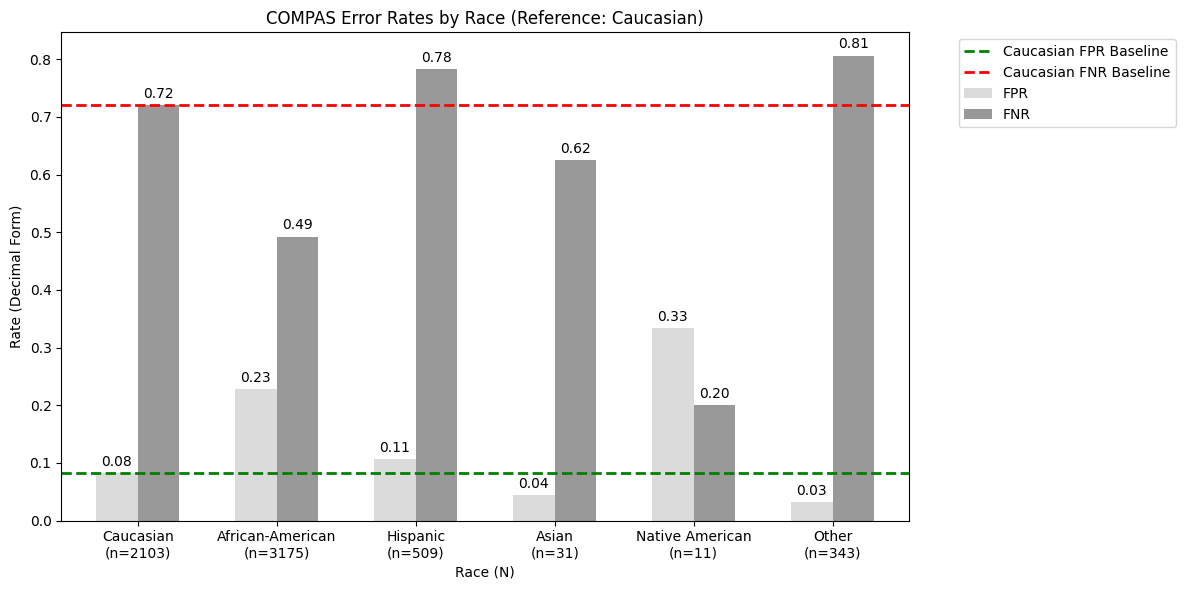

In [107]:
import matplotlib.pyplot as plt

# Calculate metrics and sample sizes in specific order with Caucasian first
races = ['Caucasian', 'African-American', 'Hispanic', 'Asian', 'Native American', 'Other']
stats = []
for race in races:
    grp = df[df['race'] == race]
    neg, pos = grp[grp['two_year_recid'] == 0], grp[grp['two_year_recid'] == 1]
    stats.append({
        'Race (N)': f"{race}\n(n={len(grp)})",
        'FPR': neg['high_risk'].mean() if len(neg) > 0 else 0,
        'FNR': (1 - pos['high_risk']).mean() if len(pos) > 0 else 0
    })

# Create DataFrame
plot_df = pd.DataFrame(stats).set_index('Race (N)')

# Get Caucasian baselines
cauc_fpr = plot_df.iloc[0]['FPR']
cauc_fnr = plot_df.iloc[0]['FNR']

# Plot
ax = plot_df.plot(kind='bar', figsize=(12, 6), width=0.6, alpha=0.8, color=['lightgrey', 'grey'])

# Add baseline lines
ax.axhline(y=cauc_fpr, color='green', linestyle='--', linewidth=2, label=f'Caucasian FPR Baseline')
ax.axhline(y=cauc_fnr, color='red', linestyle='--', linewidth=2, label=f'Caucasian FNR Baseline')

plt.title('COMPAS Error Rates by Race (Reference: Caucasian)')
plt.ylabel('Rate (Decimal Form)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()